Saved peak table with 101 rows -> xrd_peak_table.csv


,sample,two_theta_obs_deg,d_obs_A,I_norm,phase,hkl,card_id,two_theta_ref_deg,delta_deg
0,B-10Co 1000°C,33.15,2.7002,0.5183,Fe2O3 (hematite),104,ICDD 33-0664,33.100,0.050
1,B-10Co 1000°C,35.70,2.5130,0.5312,Fe2O3 (hematite),110,ICDD 33-0664,35.600,0.100
2,B-10Co 1000°C,36.15,2.4827,0.5104,TiO2 (rutile),101,ICDD 21-1276,36.100,0.050
3,B-10Co 1000°C,37.30,2.4088,0.4429,NiO (rocksalt),111,ICDD 04-0835,37.250,0.050
4,B-10Co 1000°C,41.30,2.1843,0.3741,Cr2O3 (eskolaite),113,ICDD 38-1479,41.500,-0.200
...,...,...,...,...,...,...,...,...,...
96,B-10Co-5Fe 950°C,53.70,1.7055,0.4311,None,None,None,NaN,NaN
97,B-10Co-5Fe 950°C,54.75,1.6752,0.4311,Cr2O3 (eskolaite),116,ICDD 38-1479,54.800,-0.050
98,B-10Co-5Fe 950°C,57.00,1.6143,0.5278,CoCr2O4 (spinel),511,ICDD 22-1084,57.000,0.000
99,B-10Co-5Fe 950°C,62.70,1.4806,0.5983,CoCr2O4 (spinel),440,ICDD 22-1084,62.700,0.000


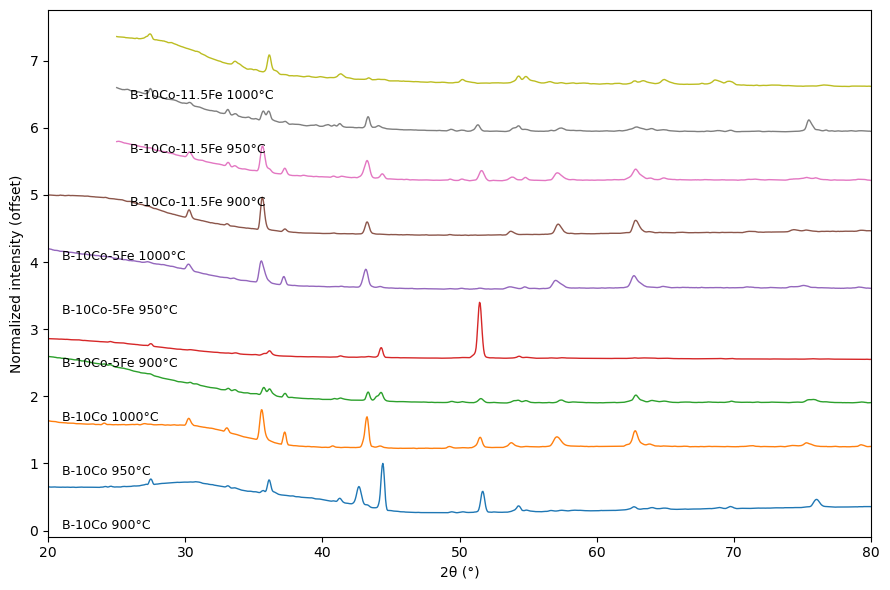

In [4]:
# SINGLE-CELL: XRD stack + peak matching (anchor CSVs) — local only, no web/APIs
# - Auto-creates phase stick library (incl. γ′–Ni3(Al,Ti) L12 with ICSD tag & angles)
# - Robust CSV reader (fixes the utf-8 decode error by trying multiple encodings)
# - Peak-pick + nearest-stick matching
# - Outputs: phase_library.csv, xrd_peak_table.csv, and a stacked plot (20–80°)

import os, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# -------- Optional SciPy (graceful fallback if absent) --------
try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ============================ CONFIG ============================
LAMBDA = 1.5406  # Cu Kα wavelength (Å)
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

# Smoothing/peaks
SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1
MATCH_TOLERANCE_DEG = 0.35

# γ′ lattice parameter (Å). You can override per-sample below.
A_GPRIME_DEFAULT = 3.58
# Optional per-sample γ′ "a" (leave empty to use default)
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
    # "B-10Co-11.5Fe 900°C": 3.565,
}

# Your anchor files
DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),

    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),

    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# ============================ HELPERS ============================
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float)
    m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5:
        return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    # fallback: moving average
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW + 1)
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kern = np.ones(w) / w
    return np.convolve(ypad, kern, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    # naive local maxima fallback
    idx = []
    for i in range(1, len(y)-1):
        if y[i] > y[i-1] and y[i] > y[i+1] and y[i] > PEAK_PROMINENCE:
            idx.append(i)
    return np.array(idx, dtype=int)

def read_anchor_csv(path):
    """Robust CSV reader: tries encodings & separators; returns two_theta + Iobs.
       Fixes 'utf-8' codec decode error by trying utf-16/cp1252/latin1."""
    encodings = ["utf-8", "utf-16", "cp1252", "latin1"]
    for enc in encodings:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        # last resort with replace errors
        with open(path, "r", encoding="latin1", errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")

    cols = {c.lower(): c for c in df.columns}
    pos_col = None
    for key, orig in cols.items():
        if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key):
            pos_col = orig; break
    iobs_col = None
    for key, orig in cols.items():
        if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key):
            iobs_col = orig; break
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs columns in {path}\nColumns: {list(df.columns)}")

    out = pd.DataFrame({
        "two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
        "Iobs":      pd.to_numeric(df[iobs_col],  errors="coerce"),
    }).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# ======================= PHASE STICK LIBRARY ======================
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    """Create phase_library.csv with sticks (incl. γ′ Ni3(Al,Ti) L12).
       γ′ is tagged with a generic ICSD descriptor."""
    rows = []
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))

    # Spinels
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)

    # Cr2O3 (eskolaite)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)

    # TiO2 (rutile)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)

    # Al2O3 (alpha)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)

    # NiO
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)

    # Hematite
    for tt,hkl in [(33.10,"104"),(35.60,"110"),(49.50,"024"),(54.10,"116")]:
        add("Fe2O3 (hematite)", "ICDD 33-0664", hkl, tt)

    # Nitrides
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)

    # Substrate γ-Ni(Co)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)

    # γ′–Ni3(Al,Ti) (L12), with generic ICSD tag (angles computed below)
    gprime_hkls = [("100",(1,0,0)), ("110",(1,1,0)), ("111",(1,1,1)),
                   ("200",(2,0,0)), ("210",(2,1,0)), ("211",(2,1,1)), ("220",(2,2,0))]
    for hkl_str,(h,k,l) in gprime_hkls:
        tt = twotheta_from_hkl(a_gprime, h,k,l)
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, tt)

    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"])\
            .sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# ======================= PROCESS ALL ANCHORS ======================
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)

profiles = []
peak_rows = []

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}")
        continue

    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"] >= TWOTHETA_MIN) & (df["two_theta"] <= TWOTHETA_MAX)]\
           .sort_values("two_theta").reset_index(drop=True)
    if df.empty:
        print(f"[WARN] no data in range for {label}")
        continue

    y_s = smooth(df["Iobs"].values)
    y_n = normalize(y_s)

    # Build a per-sample library (so γ′ angles reflect its lattice parameter if provided)
    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    idx_peaks = find_peaks_flexible(y_n)
    tt_peaks = df["two_theta"].values[idx_peaks]
    I_peaks  = y_n[idx_peaks]

    lib_tt = phase_lib["two_theta_ref_deg"].values
    for tt, ii in zip(tt_peaks, I_peaks):
        j = int(np.argmin(np.abs(lib_tt - tt)))
        if abs(lib_tt[j] - tt) <= MATCH_TOLERANCE_DEG:
            row = phase_lib.iloc[j]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], row["two_theta_ref_deg"]
            delta = tt - tt_ref
        else:
            phase, card, hkl, tt_ref, delta = (None, None, None, None, None)

        peak_rows.append({
            "sample": label,
            "two_theta_obs_deg": round(float(tt), 3),
            "d_obs_A": round(float(d_from_two_theta(tt)), 4),
            "I_norm": round(float(ii), 4),
            "phase": phase,
            "hkl": hkl,
            "card_id": card,
            "two_theta_ref_deg": None if tt_ref is None else round(float(tt_ref), 3),
            "delta_deg": None if delta   is None else round(float(delta), 3),
        })

    profiles.append((label, df["two_theta"].values, y_n))

# ============================ SAVE & PLOT ============================
peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved peak table with {len(peak_table)} rows -> xrd_peak_table.csv")
display(peak_table.groupby("sample").head(10))

plt.figure(figsize=(9, 6))
offset = 0.0
for label, tt, yy in profiles:
    plt.plot(tt, yy + offset, lw=1.0)
    if len(tt):
        plt.text(tt.min()+1.0, offset+0.03, label, fontsize=9)
    offset += 0.8

plt.xlabel("2θ (°)")
plt.ylabel("Normalized intensity (offset)")
plt.xlim(TWOTHETA_MIN, TWOTHETA_MAX)
plt.tight_layout()
plt.show()


Saved peak table with 101 rows -> xrd_peak_table.csv


C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3245482767.py:309: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.tight_layout()
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3245482767.py:310: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated.png", dpi=300, bbox_inches="tight")
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3245482767.py:311: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated.pdf", dpi=300, bbox_inches="tight")
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3245482767.py:311: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated.pdf", dpi=300, bbox_inches="tight")
C:\Users\Smart\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  fig.canvas.print_figure(bytes_io, **kw)


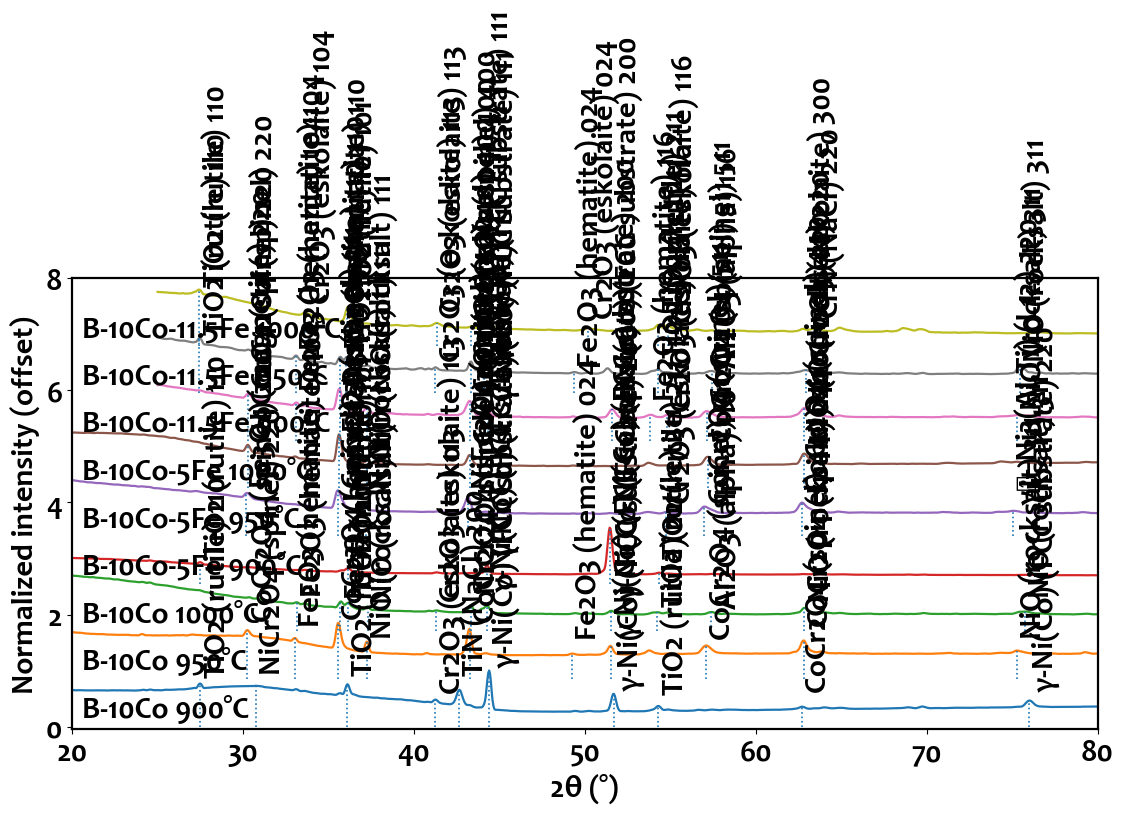

Saved:
 - phase_library.csv
 - xrd_peak_table.csv
 - xrd_stacked_annotated.png / .pdf


In [5]:
# SINGLE-CELL: XRD stack + peak matching (anchor CSVs) — local only, no web/APIs
# - Auto-creates phase stick library (incl. γ′–Ni3(Al,Ti) L12 with ICSD tag & angles)
# - Robust CSV reader (tries multiple encodings; fixes utf-8 decode errors)
# - Peak-pick + nearest-stick matching
# - Outputs: phase_library.csv, xrd_peak_table.csv, and stacked plot (annotated, 20–80°)

import os, re, math, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

# -------- Optional SciPy (graceful fallback if absent) --------
try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ============================ CONFIG ============================
LAMBDA = 1.5406  # Cu Kα wavelength (Å)
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

# Smoothing/peaks
SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1
MATCH_TOLERANCE_DEG = 0.35

# γ′ lattice parameter (Å). You can override per-sample below.
A_GPRIME_DEFAULT = 3.58
# Optional per-sample γ′ "a" (leave empty to use default)
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
    # "B-10Co-11.5Fe 900°C": 3.565,
}

# Your anchor files (edit paths if needed)
DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),

    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),

    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# Plot styling — Candara, bold 22; grid off; A4 (landscape)
def _set_candara_22_bold():
    # Try Candara; if missing, fall back and warn
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        font_family = "Candara"
    except Exception:
        font_family = matplotlib.rcParams.get("font.family", ["DejaVu Sans"])[0]
        warnings.warn("Candara font not found; using default font instead.")
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": 22,
        "font.weight": "bold",
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "axes.titleweight": "bold",
        "axes.linewidth": 1.6,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "mathtext.default": "regular",
        "grid.linestyle": "-",  # we turn grid off explicitly later
    })

# ============================ HELPERS ============================
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float)
    m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5:
        return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    # fallback: moving average
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW + 1)
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kern = np.ones(w) / w
    return np.convolve(ypad, kern, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    # naive local maxima fallback
    idx = []
    for i in range(1, len(y)-1):
        if y[i] > y[i-1] and y[i] > y[i+1] and y[i] > PEAK_PROMINENCE:
            idx.append(i)
    return np.array(idx, dtype=int)

def read_anchor_csv(path):
    """Robust CSV reader: tries encodings & separators; returns two_theta + Iobs."""
    encodings = ["utf-8", "utf-16", "cp1252", "latin1"]
    df = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        # last resort with replace errors
        with open(path, "r", encoding="latin1", errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")

    cols = {c.lower(): c for c in df.columns}
    pos_col = None
    for key, orig in cols.items():
        if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key):
            pos_col = orig; break
    iobs_col = None
    for key, orig in cols.items():
        if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key):
            iobs_col = orig; break
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs columns in {path}\nColumns: {list(df.columns)}")

    out = pd.DataFrame({
        "two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
        "Iobs":      pd.to_numeric(df[iobs_col],  errors="coerce"),
    }).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# ======================= PHASE STICK LIBRARY ======================
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    """Create phase_library.csv with sticks (incl. γ′ Ni3(Al,Ti) L12).
       γ′ is tagged with a generic ICSD descriptor."""
    rows = []
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))

    # Spinels
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)

    # Cr2O3 (eskolaite)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)

    # TiO2 (rutile)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)

    # Al2O3 (alpha)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)

    # NiO
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)

    # Hematite
    for tt,hkl in [(33.10,"104"),(35.60,"110"),(49.50,"024"),(54.10,"116")]:
        add("Fe2O3 (hematite)", "ICDD 33-0664", hkl, tt)

    # Nitrides
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)

    # Substrate γ-Ni(Co)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)

    # γ′–Ni3(Al,Ti) (L12), with generic ICSD tag (angles computed below)
    gprime_hkls = [("100",(1,0,0)), ("110",(1,1,0)), ("111",(1,1,1)),
                   ("200",(2,0,0)), ("210",(2,1,0)), ("211",(2,1,1)), ("220",(2,2,0))]
    for hkl_str,(h,k,l) in gprime_hkls:
        tt = twotheta_from_hkl(a_gprime, h,k,l)
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, tt)

    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"])\
            .sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# ======================= PROCESS ALL ANCHORS ======================
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)

profiles = []
peak_rows = []
annot_by_sample = {}  # sample -> list of (tt, y_norm, label)

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}")
        continue

    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"] >= TWOTHETA_MIN) & (df["two_theta"] <= TWOTHETA_MAX)]\
           .sort_values("two_theta").reset_index(drop=True)
    if df.empty:
        print(f"[WARN] no data in range for {label}")
        continue

    y_s = smooth(df["Iobs"].values)
    y_n = normalize(y_s)

    # Build a per-sample library (γ′ angles reflect its lattice parameter if provided)
    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    idx_peaks = find_peaks_flexible(y_n)
    tt_vals   = df["two_theta"].values
    tt_peaks  = tt_vals[idx_peaks]
    I_peaks   = y_n[idx_peaks]

    # nearest-stick matching
    lib_tt = phase_lib["two_theta_ref_deg"].values
    labels_here = []
    for tt, ii in zip(tt_peaks, I_peaks):
        j = int(np.argmin(np.abs(lib_tt - tt)))
        if abs(lib_tt[j] - tt) <= MATCH_TOLERANCE_DEG:
            row = phase_lib.iloc[j]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], row["two_theta_ref_deg"]
            delta = tt - tt_ref
            label_text = f"{phase} {hkl}"
        else:
            phase, card, hkl, tt_ref, delta = (None, None, None, None, None)
            label_text = None

        peak_rows.append({
            "sample": label,
            "two_theta_obs_deg": round(float(tt), 3),
            "d_obs_A": round(float(d_from_two_theta(tt)), 4),
            "I_norm": round(float(ii), 4),
            "phase": phase,
            "hkl": hkl,
            "card_id": card,
            "two_theta_ref_deg": None if tt_ref is None else round(float(tt_ref), 3),
            "delta_deg": None if delta   is None else round(float(delta), 3),
        })
        if label_text is not None:
            labels_here.append((tt, ii, label_text))

    # Keep only strongest N to avoid clutter
    LABEL_TOP_N = 12
    LABEL_MIN_INTENSITY = 0.12
    labels_here = sorted(labels_here, key=lambda t: t[1], reverse=True)
    labels_here = [x for x in labels_here if x[1] >= LABEL_MIN_INTENSITY][:LABEL_TOP_N]
    annot_by_sample[label] = labels_here

    profiles.append((label, tt_vals, y_n))

# ============================ SAVE TABLE ============================
peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved peak table with {len(peak_table)} rows -> xrd_peak_table.csv")

# ============================ PLOT (A4) ============================
_set_candara_22_bold()
fig, ax = plt.subplots(figsize=(11.7, 8.3))  # A4 landscape
offset = 0.0
offset_step = 0.85

for label, tt, yy in profiles:
    ax.plot(tt, yy + offset, lw=1.6, label=label)
    # Label the stack on the left
    if len(tt):
        ax.text(TWOTHETA_MIN + 0.6, offset + 0.04, label, va="bottom", ha="left")

    # Dotted trackers + phase labels
    bumps = [0.06, 0.11, 0.16, 0.21, 0.26]  # stagger labels to reduce collisions
    for k, (tt_peak, i_norm, txt) in enumerate(annot_by_sample.get(label, [])):
        ax.vlines(tt_peak, offset, offset + i_norm, linestyles=":", linewidth=1.2)
        ylab = offset + i_norm + bumps[k % len(bumps)]
        ax.text(tt_peak + 0.05, ylab, txt, rotation=90, va="bottom", ha="left")

    offset += offset_step

ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX)
ax.set_ylim(-0.05, offset + 0.35)
ax.grid(False)  # grid off
# Legend would clutter; sample labels are printed at left of each stack.

plt.tight_layout()
plt.savefig("xrd_stacked_annotated.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_annotated.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - phase_library.csv")
print(" - xrd_peak_table.csv")
print(" - xrd_stacked_annotated.png / .pdf")


Saved peak table with 101 rows -> xrd_peak_table.csv


C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3148098119.py:321: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.tight_layout()
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3148098119.py:322: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated_markers.png", dpi=300, bbox_inches="tight")
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3148098119.py:323: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated_markers.pdf", dpi=300, bbox_inches="tight")
C:\Users\Smart\AppData\Local\Temp\ipykernel_27416\3148098119.py:323: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  plt.savefig("xrd_stacked_annotated_markers.pdf", dpi=300, bbox_inches="tight")
C:\Users\Smart\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8242 (\N{PRIME}) missing from font(s) Candara.
  fig.canvas.print_figure(bytes_io, **kw)


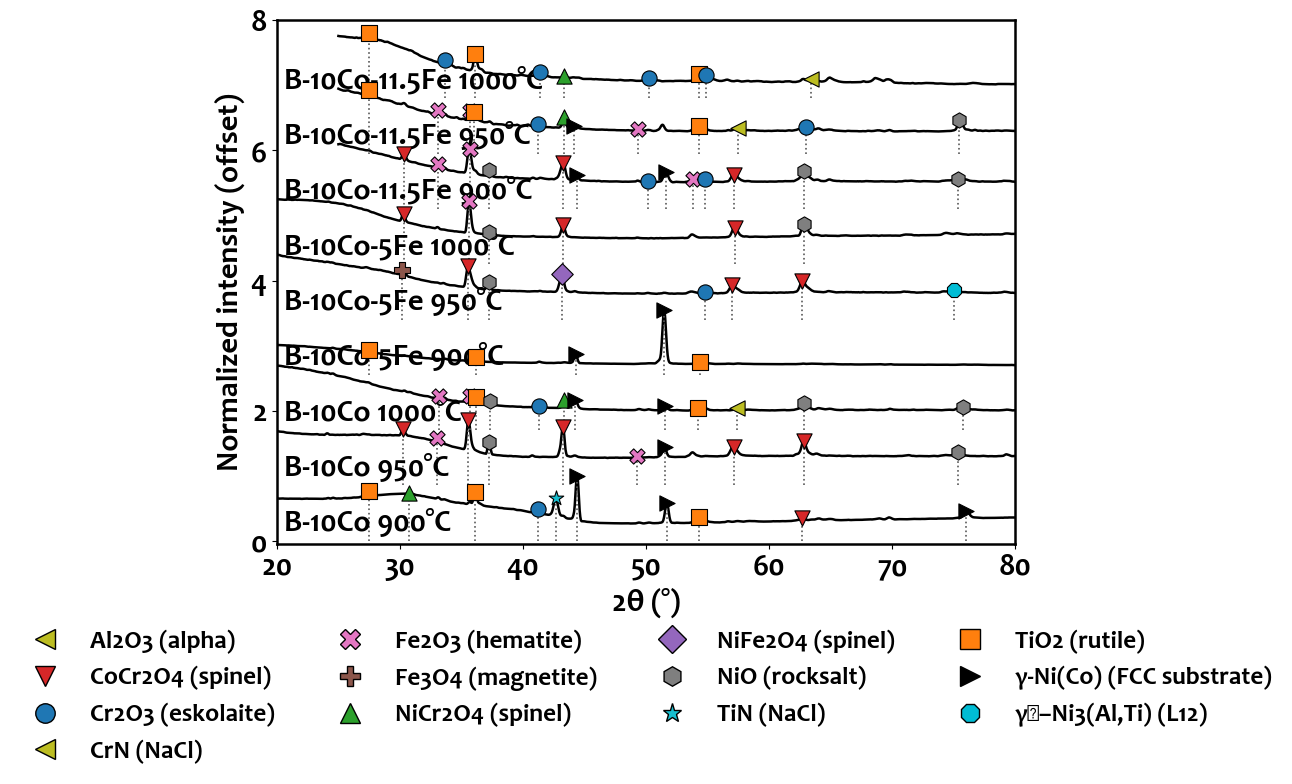

Saved:
 - phase_library.csv
 - xrd_peak_table.csv
 - xrd_stacked_annotated_markers.png / .pdf


In [6]:
# SINGLE-CELL: XRD stack + peak matching (anchor CSVs) — local only, no web/APIs
# - Auto-creates phase stick library (incl. γ′–Ni3(Al,Ti) L12 with ICSD tag & angles)
# - Robust CSV reader (tries multiple encodings; fixes utf-8 decode errors)
# - Peak-pick + nearest-stick matching
# - Outputs: phase_library.csv, xrd_peak_table.csv, and stacked plot (annotated markers, 20–80°)

import os, warnings, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

# -------- Optional SciPy (graceful fallback if absent) --------
try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ============================ CONFIG ============================
LAMBDA = 1.5406  # Cu Kα (Å)
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

# Smoothing/peaks
SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1
MATCH_TOLERANCE_DEG = 0.35

# γ′ lattice parameter (Å). Override per-sample below if you want.
A_GPRIME_DEFAULT = 3.58
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
    # "B-10Co-11.5Fe 900°C": 3.565,
}

# Anchor files
DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# Plot styling — Candara, bold 22; grid off; A4 (landscape)
def _set_candara_22_bold():
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        font_family = "Candara"
    except Exception:
        font_family = matplotlib.rcParams.get("font.family", ["DejaVu Sans"])[0]
        warnings.warn("Candara font not found; using default font.")
    plt.rcParams.update({
        "font.family": font_family,
        "font.size": 22,
        "font.weight": "bold",
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "axes.titleweight": "bold",
        "axes.linewidth": 1.8,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "mathtext.default": "regular",
    })

# ============================ HELPERS ============================
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float)
    m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5: return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW + 1)
    pad = w // 2
    ypad = np.pad(y, (pad, pad), mode="edge")
    kern = np.ones(w) / w
    return np.convolve(ypad, kern, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    idx = []
    for i in range(1, len(y)-1):
        if y[i] > y[i-1] and y[i] > y[i+1] and y[i] > PEAK_PROMINENCE:
            idx.append(i)
    return np.array(idx, dtype=int)

def read_anchor_csv(path):
    """Robust CSV reader: tries encodings & separators; returns two_theta + Iobs."""
    encodings = ["utf-8", "utf-16", "cp1252", "latin1"]
    df = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc)
            break
        except Exception:
            df = None
    if df is None:
        with open(path, "r", encoding="latin1", errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")
    cols = {c.lower(): c for c in df.columns}
    pos_col = None
    for key, orig in cols.items():
        if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key):
            pos_col = orig; break
    iobs_col = None
    for key, orig in cols.items():
        if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key):
            iobs_col = orig; break
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs in {path}\nColumns: {list(df.columns)}")
    out = pd.DataFrame({
        "two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
        "Iobs":      pd.to_numeric(df[iobs_col],  errors="coerce"),
    }).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# ======================= PHASE STICK LIBRARY ======================
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    rows = []
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))

    # Spinels
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)

    # Cr2O3 (eskolaite)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)

    # TiO2 (rutile)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)

    # Al2O3 (alpha)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)

    # NiO
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)

    # Hematite
    for tt,hkl in [(33.10,"104"),(35.60,"110"),(49.50,"024"),(54.10,"116")]:
        add("Fe2O3 (hematite)", "ICDD 33-0664", hkl, tt)

    # Nitrides
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)

    # Substrate γ-Ni(Co)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)

    # γ′–Ni3(Al,Ti) (L12) — computed angles
    gprime_hkls = [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),
                   ("200",(2,0,0)),("210",(2,1,0)),("211",(2,1,1)),("220",(2,2,0))]
    for hkl_str,(h,k,l) in gprime_hkls:
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str,
            twotheta_from_hkl(a_gprime, h,k,l))

    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"])\
            .sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# Marker + color styles per phase (extend if you like)
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "Fe2O3 (hematite)":            ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "TiN (NaCl)":                  ("*", "#17becf"),
    "CrN (NaCl)":                  ("<", "#bcbd22"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
_MARKERS = ["o","s","^","v","D","P","X","h","*","<",">","8","p"]
_COLORS  = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd","#8c564b",
            "#e377c2","#7f7f7f","#17becf","#bcbd22","#000000","#00bcd4","#2aa198"]

def phase_style(phase):
    if phase in _PHASE_STYLES:
        return _PHASE_STYLES[phase]
    # Assign a deterministic fallback style
    k = abs(hash(str(phase))) % len(_MARKERS)
    return _MARKERS[k], _COLORS[k]

# ======================= PROCESS =======================
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)

profiles = []
peak_rows = []
legend_phases = {}   # phase -> (marker,color)

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}")
        continue

    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"] >= TWOTHETA_MIN) & (df["two_theta"] <= TWOTHETA_MAX)]\
           .sort_values("two_theta").reset_index(drop=True)
    if df.empty:
        print(f"[WARN] no data in range for {label}")
        continue

    y_s = smooth(df["Iobs"].values)
    y_n = normalize(y_s)

    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    idx_peaks = find_peaks_flexible(y_n)
    tt_vals   = df["two_theta"].values
    tt_peaks  = tt_vals[idx_peaks]
    I_peaks   = y_n[idx_peaks]

    # nearest-stick matching
    lib_tt = phase_lib["two_theta_ref_deg"].values
    matches_here = []
    for tt, ii in zip(tt_peaks, I_peaks):
        j = int(np.argmin(np.abs(lib_tt - tt)))
        if abs(lib_tt[j] - tt) <= MATCH_TOLERANCE_DEG:
            row = phase_lib.iloc[j]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], row["two_theta_ref_deg"]
            delta = tt - tt_ref
            matches_here.append((tt, ii, phase, hkl))
            marker, color = phase_style(phase)
            legend_phases[phase] = (marker, color)
        else:
            phase, card, hkl, tt_ref, delta = (None, None, None, None, None)

        peak_rows.append({
            "sample": label,
            "two_theta_obs_deg": round(float(tt), 3),
            "d_obs_A": round(float(d_from_two_theta(tt)), 4),
            "I_norm": round(float(ii), 4),
            "phase": None if phase is None else phase,
            "hkl": hkl,
            "card_id": None if phase is None else row["card_id"],
            "two_theta_ref_deg": None if phase is None else round(float(tt_ref), 3),
            "delta_deg": None if phase is None else round(float(delta), 3),
        })

    profiles.append((label, tt_vals, y_n, matches_here))

# ============================ SAVE TABLE ============================
peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved peak table with {len(peak_table)} rows -> xrd_peak_table.csv")

# ============================ PLOT (A4, markers+legend) ============================
_set_candara_22_bold()
fig, ax = plt.subplots(figsize=(11.7, 8.3))  # A4 landscape
offset = 0.0
offset_step = 0.85

for label, tt, yy, matches_here in profiles:
    ax.plot(tt, yy + offset, lw=1.8, color="k")  # black traces for clarity
    # stack labels at left
    if len(tt):
        ax.text(TWOTHETA_MIN + 0.6, offset + 0.04, label, va="bottom", ha="left")
    # draw dotted trackers + marker at peak top (no text labels)
    for (tt_peak, i_norm, phase, hkl) in matches_here:
        ax.vlines(tt_peak, offset, offset + i_norm, linestyles=":", linewidth=1.2, color="0.35")
        m, c = phase_style(phase)
        ax.scatter([tt_peak], [offset + i_norm], marker=m, s=120, c=c, edgecolors="k", linewidths=0.8, zorder=5)

    offset += offset_step

ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX)
ax.set_ylim(-0.05, offset + 0.35)
ax.grid(False)

# Legend for phases only — centered below the plot
handles = []
labels = []
for ph, (mk, col) in sorted(legend_phases.items()):
    handles.append(Line2D([0],[0], marker=mk, color="none",
                          markerfacecolor=col, markeredgecolor="k",
                          markersize=14, linewidth=0, label=ph))
    labels.append(ph)

fig.subplots_adjust(bottom=0.25)  # room for legend
if handles:
    leg = ax.legend(handles=handles, labels=labels, ncol=4, loc="upper center",
                    bbox_to_anchor=(0.5, -0.12), frameon=False, fontsize=18)

plt.tight_layout()
plt.savefig("xrd_stacked_annotated_markers.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_annotated_markers.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(" - phase_library.csv")
print(" - xrd_peak_table.csv")
print(" - xrd_stacked_annotated_markers.png / .pdf")


Saved xrd_peak_table.csv (101 rows)


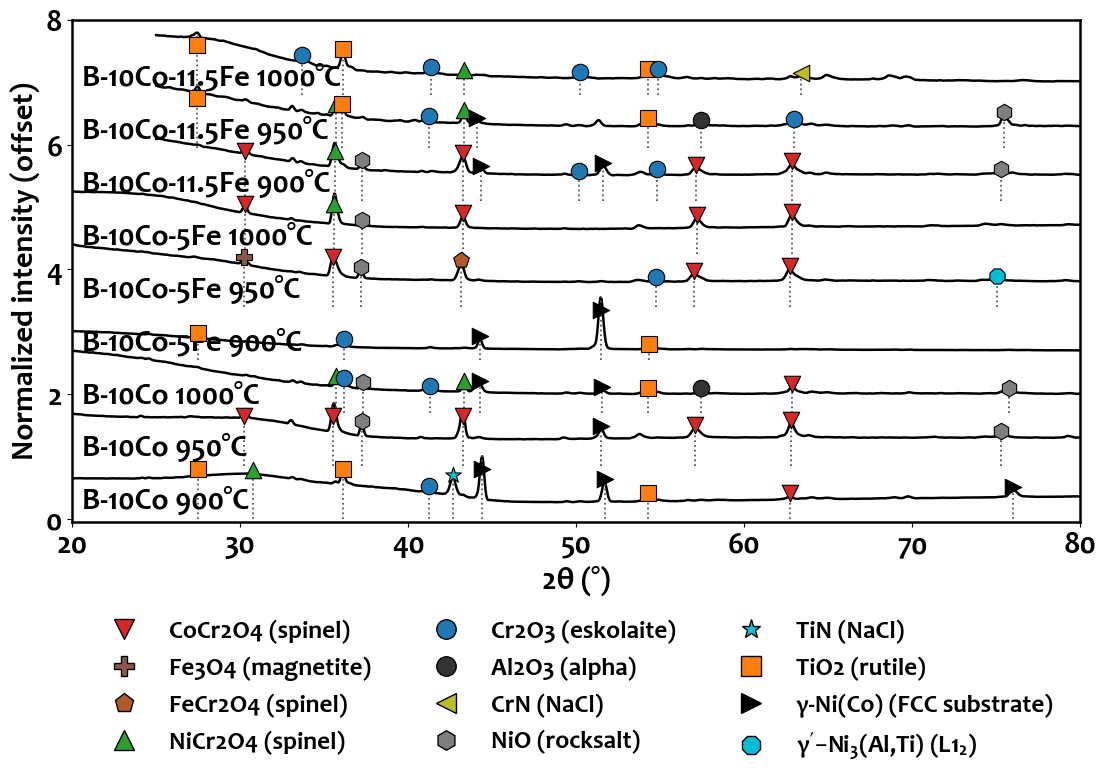

Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_annotated_markers.png/.pdf


In [7]:
# XRD stack + peak matching (anchor CSVs) — local only, no web/APIs
# Fixes:
# 1) Legend renders γ′ correctly via mathtext
# 2) Small vertical gap between marker and peak top
# 3) Matching priority: spinels > Cr2O3 > Al2O3; and no Fe-containing phases for B-10Co samples

import os, warnings, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D

try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1
MATCH_TOLERANCE_DEG = 0.35

A_GPRIME_DEFAULT = 3.58
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
}

DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# ---------- Plot style: Candara 22 bold; use mathtext for γ′ ----------
def _set_style():
    plt.rcParams['text.usetex'] = False
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        fam = "Candara"
    except Exception:
        fam = "DejaVu Sans"
        warnings.warn("Candara not found; using DejaVu Sans.")
    plt.rcParams.update({
        "font.family": fam, "font.size": 22, "font.weight": "bold",
        "axes.labelweight": "bold", "axes.linewidth": 1.8,
        "xtick.labelsize": 22, "ytick.labelsize": 22,
        "mathtext.default": "regular",
    })

# ---------------- Utils ----------------
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float); m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5: return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW+1)
    pad = w//2; ypad = np.pad(y, (pad,pad), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    idx=[]; 
    for i in range(1,len(y)-1):
        if y[i]>y[i-1] and y[i]>y[i+1] and y[i]>PEAK_PROMINENCE: idx.append(i)
    return np.array(idx, int)

def read_anchor_csv(path):
    enc = None; df=None
    for enc_try in ["utf-8","utf-16","cp1252","latin1"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc_try); enc=enc_try; break
        except Exception: pass
    if df is None:
        with open(path,"r",encoding="latin1",errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")
    cols = {c.lower(): c for c in df.columns}
    pos_col = next((orig for key,orig in cols.items() if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key)), None)
    iobs_col= next((orig for key,orig in cols.items() if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key)), None)
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs in {path}\nColumns: {list(df.columns)}")
    out = pd.DataFrame({"two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
                        "Iobs": pd.to_numeric(df[iobs_col], errors="coerce")}).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# ---------------- Phase sticks ----------------
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    rows=[]
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))
    # Spinels (priority group 0)
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(57.00,"511"),(62.60,"440")]),
        ("FeCr2O4 (spinel)","ICDD 34-0140", [(30.10,"220"),(35.40,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)
    # Cr2O3 (priority group 1)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)
    # Al2O3 (priority group 2)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)
    # Others
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)
    # γ′ L12 (angles computed)
    for hkl_str,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),("200",(2,0,0)),("210",(2,1,0)),("211",(2,1,1)),("220",(2,2,0))]:
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, twotheta_from_hkl(a_gprime,h,k,l))
    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"]).sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# Phase style + legend label mapping
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Fe2O3 (hematite)":            ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "TiN (NaCl)":                  ("*", "#17becf"),
    "CrN (NaCl)":                  ("<", "#bcbd22"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
LEGEND_LABEL = {
    "γ′–Ni3(Al,Ti) (L12)": r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)"
}

def phase_style(phase):
    return _PHASE_STYLES.get(phase, ("o", "#333333"))

# Priority mapping: lower is higher priority
def phase_priority(phase):
    name = str(phase)
    if "(spinel)" in name or "Fe3O4" in name: return 0
    if name.startswith("Cr2O3"): return 1
    if name.startswith("Al2O3"): return 2
    return 3

def phase_allowed(sample_label, phase_name):
    # Block Fe phases for B-10Co (no Fe added)
    if sample_label.startswith("B-10Co ") and ("-5Fe" not in sample_label) and ("-11.5Fe" not in sample_label):
        for fe_tag in ["Fe2O3","Fe3O4","NiFe2O4","FeCr2O4"]:
            if fe_tag in phase_name: return False
    return True

# ---------------- Process ----------------
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)
profiles = []; peak_rows = []; legend_phases = {}

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}"); continue
    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"]>=TWOTHETA_MIN)&(df["two_theta"]<=TWOTHETA_MAX)].sort_values("two_theta").reset_index(drop=True)
    if df.empty: print(f"[WARN] no data in range for {label}"); continue

    y = normalize(smooth(df["Iobs"].values))
    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    idx = find_peaks_flexible(y)
    tt = df["two_theta"].values
    tt_peaks, I_peaks = tt[idx], y[idx]

    # Candidate-based matching with priority + per-sample allow-list
    matches_here = []
    for tpk, ipk in zip(tt_peaks, I_peaks):
        diffs = np.abs(phase_lib["two_theta_ref_deg"].values - tpk)
        cand_idx = np.where(diffs <= MATCH_TOLERANCE_DEG)[0]
        best = None; best_cost = 1e9
        for j in cand_idx:
            ph = phase_lib.iloc[j]["phase"]
            if not phase_allowed(label, ph): 
                continue
            cost = diffs[j] + 0.05*phase_priority(ph)  # bias by priority
            if cost < best_cost: 
                best_cost = cost; best = j
        if best is not None:
            row = phase_lib.iloc[best]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], float(row["two_theta_ref_deg"])
            delta = float(tpk - tt_ref)
            matches_here.append((tpk, ipk, phase, hkl))
            legend_phases[phase] = phase_style(phase)
            peak_rows.append({
                "sample": label, "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(ipk),4), "phase": phase, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(delta,3),
            })
        else:
            peak_rows.append({
                "sample": label, "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(ipk),4), "phase": None, "hkl": None,
                "card_id": None, "two_theta_ref_deg": None, "delta_deg": None,
            })
    profiles.append((label, tt, y, matches_here))

peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved xrd_peak_table.csv ({len(peak_table)} rows)")

# ---------------- Plot with markers, dotted trackers, A4, legend below ----------------
_set_style()
fig, ax = plt.subplots(figsize=(11.7, 8.3))  # A4 landscape
offset = 0.0; offset_step = 0.85
MARKER_DY = 0.05  # small vertical gap above peak top

for label, tt, yy, matches_here in profiles:
    ax.plot(tt, yy + offset, lw=1.8, color="k")
    if len(tt): ax.text(TWOTHETA_MIN+0.6, offset+0.04, label, va="bottom", ha="left")
    # markers with little vertical gap + dotted tracker
    lane_top = offset + offset_step - 0.05
    for tpk, ipk, phase, hkl in matches_here:
        ax.vlines(tpk, offset, offset + ipk, linestyles=":", linewidth=1.3, color="0.35")
        m, c = phase_style(phase)
        ymark = min(offset + ipk + MARKER_DY, lane_top)
        ax.scatter([tpk], [ymark], marker=m, s=140, c=c, edgecolors="k", linewidths=0.8, zorder=5)
    offset += offset_step

ax.set_xlabel("2θ (°)"); ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX); ax.set_ylim(-0.05, offset + 0.35); ax.grid(False)

# Legend (phases only) below
handles=[]; labels=[]
for ph in sorted(legend_phases.keys(), key=lambda x: (phase_priority(x), x)):
    mk, col = legend_phases[ph]
    handles.append(Line2D([0],[0], marker=mk, color="none", markerfacecolor=col,
                          markeredgecolor="k", markersize=14, linewidth=0, label=ph))
    labels.append(LEGEND_LABEL.get(ph, ph))

fig.subplots_adjust(bottom=0.27)
if handles:
    ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center",
              bbox_to_anchor=(0.5, -0.15), frameon=False, fontsize=18)

plt.tight_layout()
plt.savefig("xrd_stacked_annotated_markers.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_annotated_markers.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_annotated_markers.png/.pdf")


Saved xrd_peak_table.csv (101 rows)


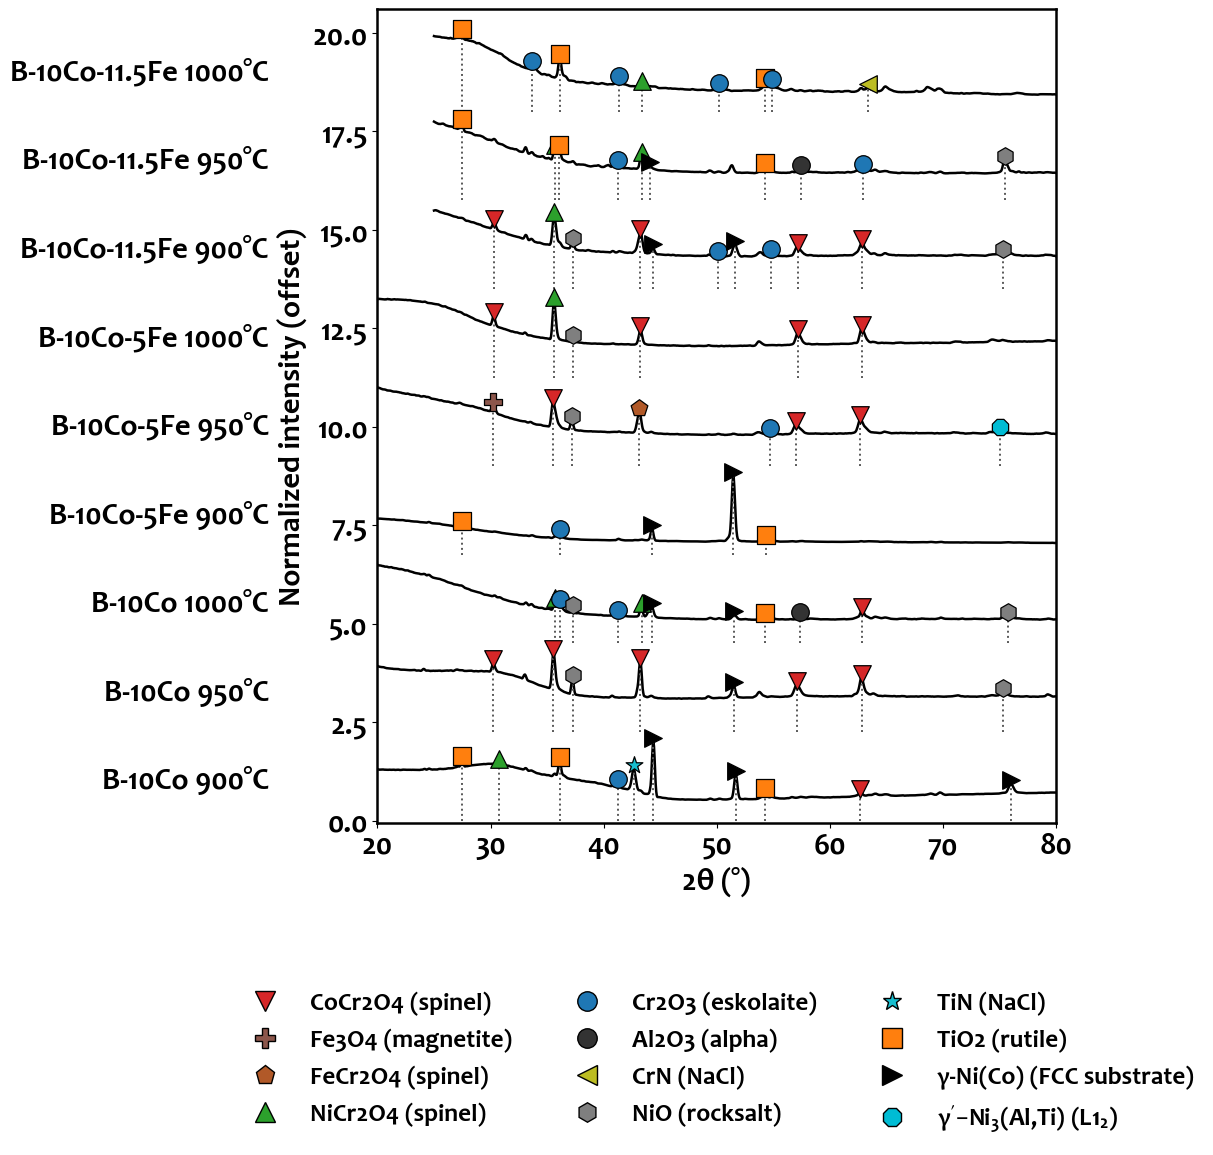

Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf


In [10]:
# XRD stack + prioritized peak matching (anchor CSVs) — local only, no web/APIs
# Change: sample labels moved further LEFT outside the y-axis; left margin widened.

import os, warnings, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib import transforms as mtrans

try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1
MATCH_TOLERANCE_DEG = 0.35

A_GPRIME_DEFAULT = 3.58
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
}

DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# -------- Style (Candara 22 bold) --------
def _set_style():
    plt.rcParams['text.usetex'] = False
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        fam = "Candara"
    except Exception:
        fam = "DejaVu Sans"
        warnings.warn("Candara not found; using DejaVu Sans.")
    plt.rcParams.update({
        "font.family": fam, "font.size": 22, "font.weight": "bold",
        "axes.labelweight": "bold", "axes.linewidth": 1.8,
        "xtick.labelsize": 22, "ytick.labelsize": 22,
        "mathtext.default": "regular",
    })

# -------- Utilities --------
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float); m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5: return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW+1)
    pad = w//2; ypad = np.pad(y, (pad,pad), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    idx=[]
    for i in range(1,len(y)-1):
        if y[i]>y[i-1] and y[i]>y[i+1] and y[i]>PEAK_PROMINENCE: idx.append(i)
    return np.array(idx, int)

def read_anchor_csv(path):
    enc=None; df=None
    for enc_try in ["utf-8","utf-16","cp1252","latin1"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc_try); enc=enc_try; break
        except Exception: pass
    if df is None:
        with open(path,"r",encoding="latin1",errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")
    cols = {c.lower(): c for c in df.columns}
    pos_col = next((orig for key,orig in cols.items() if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key)), None)
    iobs_col= next((orig for key,orig in cols.items() if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key)), None)
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs in {path}\nColumns: {list(df.columns)}")
    out = pd.DataFrame({"two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
                        "Iobs": pd.to_numeric(df[iobs_col], errors="coerce")}).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# -------- Phase library (with γ′) --------
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    rows=[]
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))
    # Spinels (priority 0)
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(57.00,"511"),(62.60,"440")]),
        ("FeCr2O4 (spinel)","ICDD 34-0140", [(30.10,"220"),(35.40,"311"),(43.10,"400"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)
    # Cr2O3 (priority 1)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)
    # Al2O3 (priority 2)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)
    # Others
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)
    # γ′ L12
    for hkl_str,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),("200",(2,0,0)),("210",(2,1,0)),("211",(2,1,1)),("220",(2,2,0))]:
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, twotheta_from_hkl(a_gprime,h,k,l))
    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"]).sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# ---- Phase style & legend labels ----
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Fe2O3 (hematite)":            ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "TiN (NaCl)":                  ("*", "#17becf"),
    "CrN (NaCl)":                  ("<", "#bcbd22"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
LEGEND_LABEL = {
    "γ′–Ni3(Al,Ti) (L12)": r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)"
}
def phase_style(phase): return _PHASE_STYLES.get(phase, ("o","#333333"))

def phase_priority(phase):
    name = str(phase)
    if "(spinel)" in name or "Fe3O4" in name: return 0
    if name.startswith("Cr2O3"): return 1
    if name.startswith("Al2O3"): return 2
    return 3

def phase_allowed(sample_label, phase_name):
    if sample_label.startswith("B-10Co ") and ("-5Fe" not in sample_label) and ("-11.5Fe" not in sample_label):
        for fe_tag in ["Fe2O3","Fe3O4","NiFe2O4","FeCr2O4"]:
            if fe_tag in phase_name: return False
    return True

# ---------------- Read & match ----------------
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)
profiles = []; peak_rows = []; legend_phases = {}

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f("[WARN] missing: {fpath}")); continue
    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"]>=TWOTHETA_MIN)&(df["two_theta"]<=TWOTHETA_MAX)].sort_values("two_theta").reset_index(drop=True)
    if df.empty: print(f"[WARN] no data in range for {label}"); continue

    y = normalize(smooth(df["Iobs"].values))
    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    idx = find_peaks_flexible(y)
    tt = df["two_theta"].values
    tt_peaks, I_peaks = tt[idx], y[idx]

    matches_here = []
    diffs_all = np.abs(phase_lib["two_theta_ref_deg"].values.reshape(1,-1) - tt_peaks.reshape(-1,1))
    for ip, tpk in enumerate(tt_peaks):
        cand_idx = np.where(diffs_all[ip] <= MATCH_TOLERANCE_DEG)[0]
        best = None; best_cost = 1e9
        for j in cand_idx:
            ph = phase_lib.iloc[j]["phase"]
            if not phase_allowed(label, ph): 
                continue
            cost = diffs_all[ip, j] + 0.05*phase_priority(ph)
            if cost < best_cost: 
                best_cost = cost; best = j
        if best is not None:
            row = phase_lib.iloc[best]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], float(row["two_theta_ref_deg"])
            delta = float(tpk - tt_ref)
            matches_here.append((tpk, I_peaks[ip], phase, hkl))
            legend_phases[phase] = phase_style(phase)
            peak_rows.append({
                "sample": label, "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4), "phase": phase, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(delta,3),
            })
        else:
            peak_rows.append({
                "sample": label, "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4), "phase": None, "hkl": None,
                "card_id": None, "two_theta_ref_deg": None, "delta_deg": None,
            })
    profiles.append((label, tt, y, matches_here))

peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved xrd_peak_table.csv ({len(peak_table)} rows)")

# ---------------- Plot (labels further outside, double height, dynamic size) ----------------
_set_style()

HEIGHT_SCALE = 2.0                  # double the peak height
OFFSET_STEP  = HEIGHT_SCALE + 0.25  # spacing between lanes
N = len(profiles)
fig_width = 11.7
fig_height = max(8.3, 1.0 + N * (OFFSET_STEP * 0.55))  # grow with N
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Leave a wider left margin to accommodate labels that are farther outside
LEFT_MARGIN = 0.40     # was 0.32
BOTTOM_MARGIN = 0.30
fig.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.97, bottom=BOTTOM_MARGIN)

offset = 0.0
MARKER_DY = 0.10  # vertical gap above peak top
LABEL_X_AXES = -0.16  # move labels further left (was -0.10)

# blended transform: x in axes fraction (to the LEFT of y-axis), y in data coords (lane positions)
text_trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

for label, tt, yy, matches_here in profiles:
    yy2 = yy * HEIGHT_SCALE
    ax.plot(tt, yy2 + offset, lw=1.8, color="k")

    # sample label OUTSIDE the y-axis, further left
    ax.text(LABEL_X_AXES, offset + HEIGHT_SCALE*0.50, label, transform=text_trans,
            ha="right", va="center")

    lane_top = offset + OFFSET_STEP - 0.05
    for tpk, ipk, phase, hkl in matches_here:
        ax.vlines(tpk, offset, offset + ipk*HEIGHT_SCALE, linestyles=":", linewidth=1.4, color="0.35")
        m, c = _PHASE_STYLES.get(phase, ("o","#333333"))
        ymark = min(offset + ipk*HEIGHT_SCALE + MARKER_DY, lane_top)
        ax.scatter([tpk], [ymark], marker=m, s=160, c=c, edgecolors="k", linewidths=0.9, zorder=5)
    offset += OFFSET_STEP

ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX)
ax.set_ylim(-0.05, offset + 0.35)
ax.grid(False)

# Legend below (priority ordering)
handles=[]; labels=[]
def phase_priority_key(x): 
    return (0 if "(spinel)" in x or "Fe3O4" in x else (1 if x.startswith("Cr2O3") else (2 if x.startswith("Al2O3") else 3)), x)
for ph in sorted(set(legend_phases.keys()), key=phase_priority_key):
    mk, col = _PHASE_STYLES.get(ph, ("o","#333333"))
    handles.append(Line2D([0],[0], marker=mk, color="none", markerfacecolor=col,
                          markeredgecolor="k", markersize=14, linewidth=0, label=ph))
    labels.append(LEGEND_LABEL.get(ph, ph))

if handles:
    ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center",
              bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=18)

plt.savefig("xrd_stacked_outside_labels.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_outside_labels.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf")


Saved xrd_peak_table.csv (101 rows)


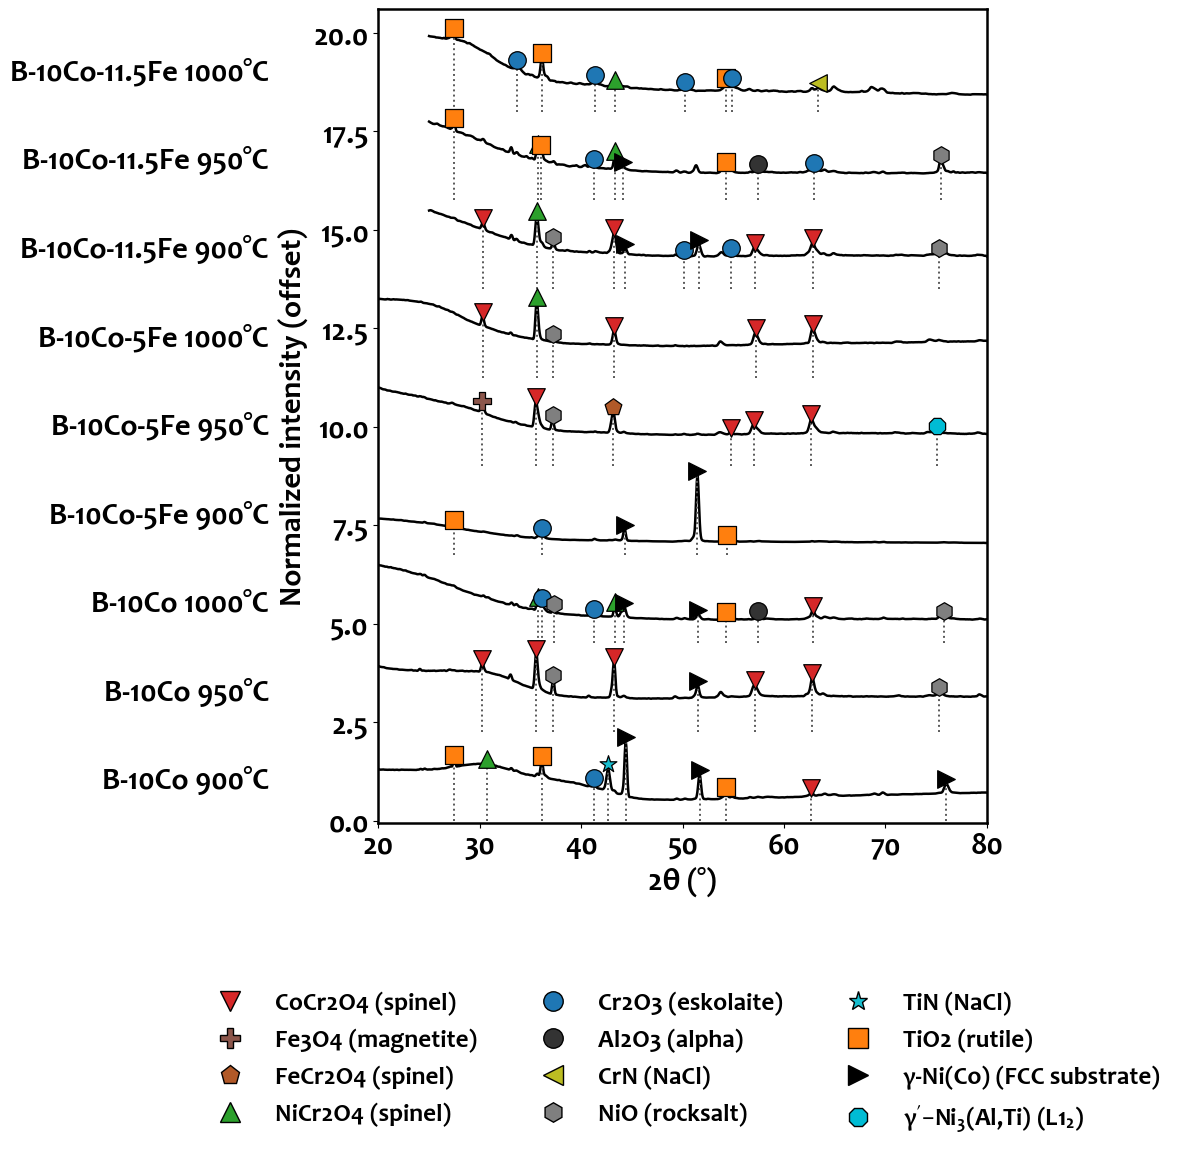

Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf


In [11]:
# XRD stack + prioritized + stick-driven matching (anchor CSVs) — local only, no web/APIs
# Updates in this cell:
# - Two-pass matching: (1) peak→stick best match, (2) stick-driven sweep for priority phases
# - Priority order: spinels > Cr2O3 > Al2O3 (and suppress Fe phases for B-10Co)
# - More sticks per phase to catch additional peaks (e.g., spinel (422))
# - Sample labels moved farther LEFT outside; larger left margin
# - Clearer plotting: dotted guide lines + markers; legend below

import os, warnings, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib import transforms as mtrans

try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE = 0.02
PEAK_WIDTH     = 1

MATCH_TOLERANCE_DEG_P1 = 0.35   # pass-1 tolerance (peak → nearest stick)
MATCH_TOLERANCE_DEG_P2 = 0.30   # pass-2 tolerance (stick → nearest peak), slightly stricter

A_GPRIME_DEFAULT = 3.58
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
}

DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# -------- Style (Candara 22 bold) --------
def _set_style():
    plt.rcParams['text.usetex'] = False
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        fam = "Candara"
    except Exception:
        fam = "DejaVu Sans"
        warnings.warn("Candara not found; using DejaVu Sans.")
    plt.rcParams.update({
        "font.family": fam, "font.size": 22, "font.weight": "bold",
        "axes.labelweight": "bold", "axes.linewidth": 1.8,
        "xtick.labelsize": 22, "ytick.labelsize": 22,
        "mathtext.default": "regular",
    })

# -------- Utilities --------
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float); m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5: return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW+1)
    pad = w//2; ypad = np.pad(y, (pad,pad), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def find_peaks_flexible(y):
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=PEAK_PROMINENCE, width=PEAK_WIDTH)
        return idx
    idx=[]
    for i in range(1,len(y)-1):
        if y[i]>y[i-1] and y[i]>y[i+1] and y[i]>PEAK_PROMINENCE: idx.append(i)
    return np.array(idx, int)

def read_anchor_csv(path):
    enc=None; df=None
    for enc_try in ["utf-8","utf-16","cp1252","latin1"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc_try); enc=enc_try; break
        except Exception: pass
    if df is None:
        with open(path,"r",encoding="latin1",errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")
    cols = {c.lower(): c for c in df.columns}
    pos_col = next((orig for key,orig in cols.items() if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key)), None)
    iobs_col= next((orig for key,orig in cols.items() if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key)), None)
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs in {path}\nColumns: {list(df.columns)}")
    out = pd.DataFrame({"two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
                        "Iobs": pd.to_numeric(df[iobs_col], errors="coerce")}).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# -------- Phase library (with γ′) --------
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    rows=[]
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))
    # Spinels (priority 0) – include (422) too
    for phase, card, sticks in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615", [(30.45,"220"),(35.60,"311"),(43.35,"400"),(54.70,"422"),(57.00,"511"),(62.70,"440")]),
        ("CoCr2O4 (spinel)", "ICDD 22-1084", [(30.35,"220"),(35.55,"311"),(43.30,"400"),(54.70,"422"),(57.00,"511"),(62.70,"440")]),
        ("NiFe2O4 (spinel)","ICDD 10-0325", [(30.10,"220"),(35.45,"311"),(43.10,"400"),(54.70,"422"),(57.00,"511"),(62.60,"440")]),
        ("Fe3O4 (magnetite)","ICDD 19-0629",[(30.10,"220"),(35.50,"311"),(43.20,"400"),(54.70,"422"),(57.00,"511"),(62.60,"440")]),
        ("FeCr2O4 (spinel)","ICDD 34-0140", [(30.10,"220"),(35.40,"311"),(43.10,"400"),(54.70,"422"),(57.00,"511"),(62.60,"440")]),
    ]:
        for tt,hkl in sticks: add(phase, card, hkl, tt)
    # Cr2O3 (priority 1)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)
    # Al2O3 (priority 2)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)
    # Others
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)
    # γ′ L12
    for hkl_str,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),("200",(2,0,0)),("210",(2,1,0)),("211",(2,1,1)),("220",(2,2,0))]:
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, twotheta_from_hkl(a_gprime,h,k,l))
    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"]).sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# ---- Phase style & legend labels ----
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Fe2O3 (hematite)":            ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "TiN (NaCl)":                  ("*", "#17becf"),
    "CrN (NaCl)":                  ("<", "#bcbd22"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
LEGEND_LABEL = {
    "γ′–Ni3(Al,Ti) (L12)": r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)"
}
def phase_style(phase): return _PHASE_STYLES.get(phase, ("o","#333333"))

def phase_priority(phase):
    name = str(phase)
    if "(spinel)" in name or "Fe3O4" in name: return 0
    if name.startswith("Cr2O3"): return 1
    if name.startswith("Al2O3"): return 2
    return 3

def phase_allowed(sample_label, phase_name):
    # Suppress Fe-containing phases for Fe-free B-10Co samples
    if sample_label.startswith("B-10Co ") and ("-5Fe" not in sample_label) and ("-11.5Fe" not in sample_label):
        for fe_tag in ["Fe2O3","Fe3O4","NiFe2O4","FeCr2O4"]:
            if fe_tag in phase_name: return False
    return True

# ---------------- Read & match (two-pass) ----------------
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)
profiles = []; peak_rows = []; legend_phases = {}

PRIORITY_PHASES = [
    "NiCr2O4 (spinel)", "CoCr2O4 (spinel)", "NiFe2O4 (spinel)", "Fe3O4 (magnetite)", "FeCr2O4 (spinel)",
    "Cr2O3 (eskolaite)",
    "Al2O3 (alpha)"
]

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}"); continue

    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"]>=TWOTHETA_MIN)&(df["two_theta"]<=TWOTHETA_MAX)].sort_values("two_theta").reset_index(drop=True)
    if df.empty:
        print(f"[WARN] no data in range for {label}"); continue

    y = normalize(smooth(df["Iobs"].values))
    tt = df["two_theta"].values

    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    # --- Pass 1: Peak -> nearest stick (with priority in cost)
    idx = find_peaks_flexible(y)
    tt_peaks, I_peaks = tt[idx], y[idx]

    matches_here = []                # (two_theta, I_norm, phase, hkl)
    matched_peak_mask = np.zeros(len(tt_peaks), dtype=bool)

    diffs_all = np.abs(phase_lib["two_theta_ref_deg"].values.reshape(1,-1) - tt_peaks.reshape(-1,1))
    for ip, tpk in enumerate(tt_peaks):
        cand_idx = np.where(diffs_all[ip] <= MATCH_TOLERANCE_DEG_P1)[0]
        best = None; best_cost = 1e9
        for j in cand_idx:
            ph = phase_lib.iloc[j]["phase"]
            if not phase_allowed(label, ph): 
                continue
            cost = diffs_all[ip, j] + 0.05*phase_priority(ph)
            if cost < best_cost: 
                best_cost = cost; best = j
        if best is not None:
            row = phase_lib.iloc[best]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], float(row["two_theta_ref_deg"])
            delta = float(tpk - tt_ref)
            matched_peak_mask[ip] = True
            matches_here.append((tpk, I_peaks[ip], phase, hkl))
            legend_phases[phase] = phase_style(phase)
            peak_rows.append({
                "sample": label, "pass": "P1",
                "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4),
                "phase": phase, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(delta,3),
            })
        else:
            peak_rows.append({
                "sample": label, "pass": "P1",
                "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4),
                "phase": None, "hkl": None,
                "card_id": None, "two_theta_ref_deg": None, "delta_deg": None,
            })

    # --- Pass 2: Stick-driven sweep for priority phases (label more peaks of same phase)
    for ph_name in PRIORITY_PHASES:
        # skip Fe phases for Fe-free B-10Co
        if not phase_allowed(label, ph_name): 
            continue
        stick_rows = phase_lib[phase_lib["phase"]==ph_name]
        for _, r in stick_rows.iterrows():
            tt_ref = float(r["two_theta_ref_deg"]); hkl = r["hkl"]; card = r["card_id"]
            # find nearest UNMATCHED peak to this stick
            diffs = np.abs(tt_peaks - tt_ref)
            # consider only peaks within P2 tolerance and currently unmatched
            cand = np.where((diffs <= MATCH_TOLERANCE_DEG_P2) & (~matched_peak_mask))[0]
            if cand.size == 0:
                continue
            ip_best = cand[np.argmin(diffs[cand])]
            tpk, ipk = float(tt_peaks[ip_best]), float(I_peaks[ip_best])
            matched_peak_mask[ip_best] = True
            matches_here.append((tpk, ipk, ph_name, hkl))
            legend_phases[ph_name] = phase_style(ph_name)
            peak_rows.append({
                "sample": label, "pass": "P2",
                "two_theta_obs_deg": round(tpk,3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(ipk,4),
                "phase": ph_name, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(tpk-tt_ref,3),
            })

    profiles.append((label, tt, y, matches_here))

# ---------------- Save table ----------------
peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg","pass"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved xrd_peak_table.csv ({len(peak_table)} rows)")

# ---------------- Plot (labels farther outside, double height, dynamic size) ----------------
_set_style()

HEIGHT_SCALE = 2.0                  # double the peak height
OFFSET_STEP  = HEIGHT_SCALE + 0.25  # spacing between lanes
N = len(profiles)
fig_width = 11.7
fig_height = max(8.3, 1.0 + N * (OFFSET_STEP * 0.55))  # grow with N
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# Wider left margin for labels that sit farther outside
LEFT_MARGIN = 0.46     # increased
BOTTOM_MARGIN = 0.30
fig.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.97, bottom=BOTTOM_MARGIN)

offset = 0.0
MARKER_DY = 0.12       # small vertical gap above peak top
LABEL_X_AXES = -0.18   # place labels further left (outside)

text_trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

for label, tt, yy, matches_here in profiles:
    yy2 = yy * HEIGHT_SCALE
    ax.plot(tt, yy2 + offset, lw=1.8, color="k")

    # sample label OUTSIDE, further left
    ax.text(LABEL_X_AXES, offset + HEIGHT_SCALE*0.50, label, transform=text_trans,
            ha="right", va="center")

    lane_top = offset + OFFSET_STEP - 0.05
    for tpk, ipk, phase, hkl in matches_here:
        ax.vlines(tpk, offset, offset + ipk*HEIGHT_SCALE, linestyles=":", linewidth=1.4, color="0.35")
        m, c = _PHASE_STYLES.get(phase, ("o","#333333"))
        ymark = min(offset + ipk*HEIGHT_SCALE + MARKER_DY, lane_top)
        ax.scatter([tpk], [ymark], marker=m, s=160, c=c, edgecolors="k", linewidths=0.9, zorder=5)
    offset += OFFSET_STEP

ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX)
ax.set_ylim(-0.05, offset + 0.35)
ax.grid(False)

# Legend (priority ordering) below
handles=[]; labels=[]
def phase_priority_key(x): 
    return (0 if "(spinel)" in x or "Fe3O4" in x else (1 if x.startswith("Cr2O3") else (2 if x.startswith("Al2O3") else 3)), x)
for ph in sorted(set([r["phase"] for r in peak_rows if r.get("phase")]), key=phase_priority_key):
    mk, col = _PHASE_STYLES.get(ph, ("o","#333333"))
    handles.append(Line2D([0],[0], marker=mk, color="none", markerfacecolor=col,
                          markeredgecolor="k", markersize=14, linewidth=0, label=ph))
    labels.append(LEGEND_LABEL.get(ph, ph))

if handles:
    ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center",
              bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=18)

plt.savefig("xrd_stacked_outside_labels.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_outside_labels.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf")


Saved xrd_peak_table.csv (258 rows)


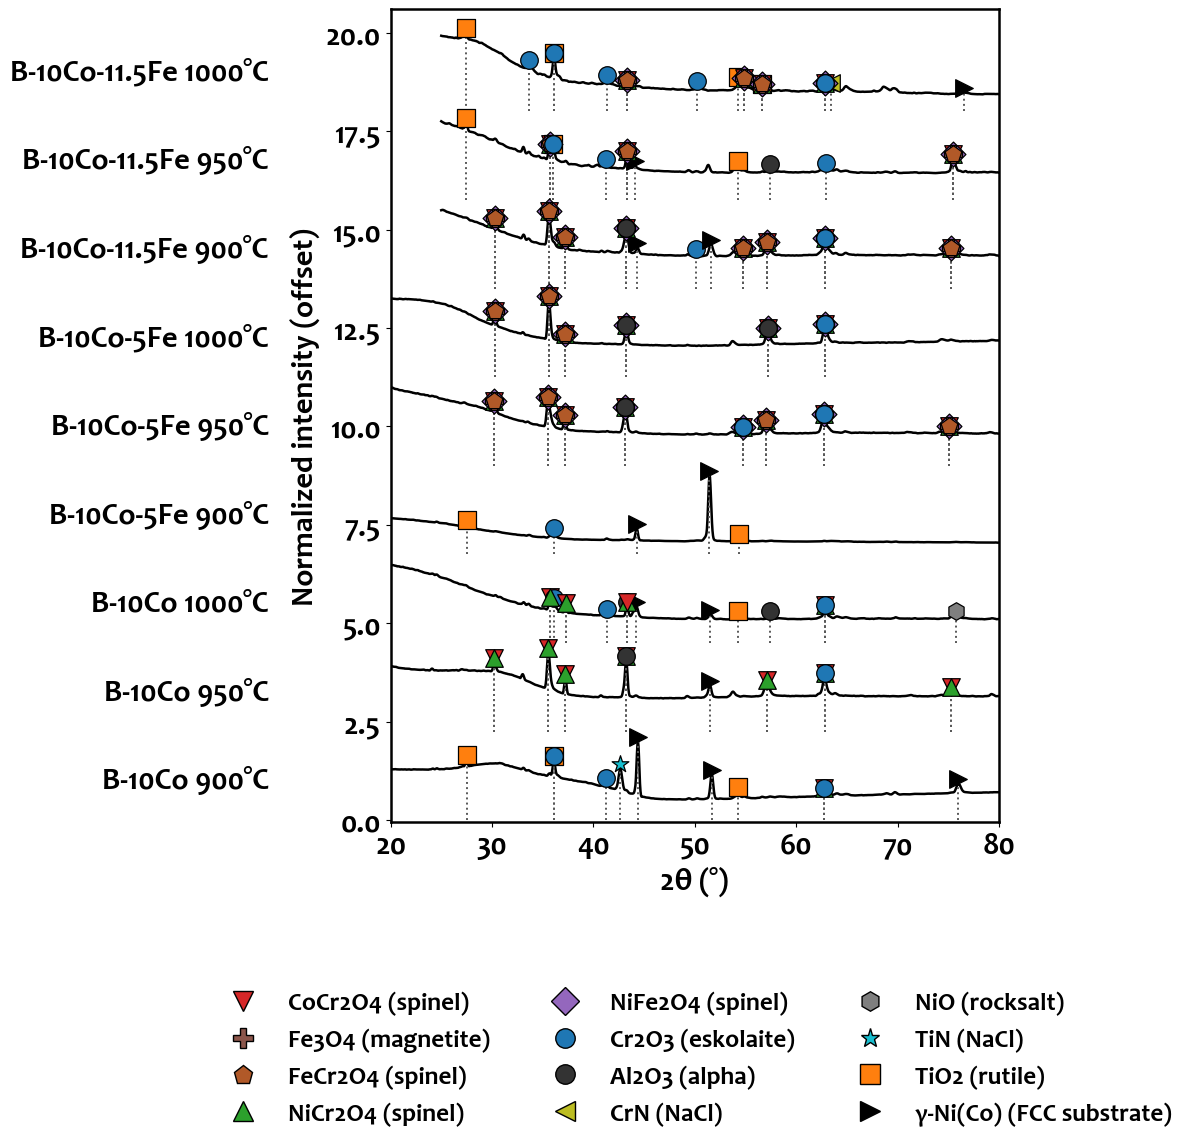

Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf


In [12]:
# XRD stack + prioritized spinel matching (anchor CSVs) — local only, no web/APIs
# Focus: match more spinels for B-10Co-11.5Fe @ 1000 °C
# - Adds more spinel sticks (222, 331/420, 620, 533, 622, 444) in 20–80°
# - Pass-2 (stick→peak) uses wider tolerance and lower prominence ONLY for that sample
# - Allows multiple spinel sticks to map to the same observed peak (no over-masking)
# - Keeps Fe-phase suppression for Fe-free B-10Co samples
# - Labels remain outside the y-axis; legend below

import os, warnings, numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import transforms as mtrans

try:
    from scipy.signal import savgol_filter, find_peaks
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0

SMOOTH_WINDOW = 9
SMOOTH_POLY   = 3
PEAK_PROMINENCE_BASE = 0.02
PEAK_WIDTH     = 1

# Match tolerances
MATCH_TOLERANCE_DEG_P1 = 0.35   # pass-1 (peak→stick)
MATCH_TOLERANCE_DEG_P2 = 0.30   # pass-2 (stick→peak, default)
MATCH_TOLERANCE_DEG_P2_SPINEL_BOOST = 0.45  # pass-2 for spinels in target sample

# Target sample to boost spinel matching
TARGET_LABEL = "B-10Co-11.5Fe 1000°C"
TARGET_P2_PROMINENCE = 0.015  # slightly lower to capture weaker spinel lines

A_GPRIME_DEFAULT = 3.58
SAMPLE_TO_A_GPRIME = {
    # "B-10Co 900°C": 3.585,
}

DATA_FILES = [
    ("B-10Co 900°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",   r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\B10Co10Fe 1000 anchor.CSV"),
]

# -------- Style (Candara 22 bold) --------
def _set_style():
    plt.rcParams['text.usetex'] = False
    try:
        matplotlib.font_manager.findfont("Candara", fallback_to_default=False)
        fam = "Candara"
    except Exception:
        fam = "DejaVu Sans"
        warnings.warn("Candara not found; using DejaVu Sans.")
    plt.rcParams.update({
        "font.family": fam, "font.size": 22, "font.weight": "bold",
        "axes.labelweight": "bold", "axes.linewidth": 1.8,
        "xtick.labelsize": 22, "ytick.labelsize": 22,
        "mathtext.default": "regular",
    })

# -------- Utilities --------
def twotheta_from_hkl(a, h,k,l, lam=LAMBDA):
    d = a / np.sqrt(h*h + k*k + l*l)
    theta = np.degrees(np.arcsin(lam/(2.0*d)))
    return 2.0*theta

def d_from_two_theta(two_theta_deg, lam=LAMBDA):
    theta = np.radians(two_theta_deg/2.0)
    return lam / (2.0*np.sin(theta))

def normalize(y):
    y = np.asarray(y, float); m = np.nanmax(y) if y.size else 0.0
    return y if m <= 0 else y/m

def smooth(y):
    y = np.asarray(y, float)
    if y.size < 5: return y
    if _HAVE_SCIPY and y.size >= SMOOTH_WINDOW:
        return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
    w = max(3, SMOOTH_WINDOW if SMOOTH_WINDOW % 2 else SMOOTH_WINDOW+1)
    pad = w//2; ypad = np.pad(y, (pad,pad), mode="edge")
    return np.convolve(ypad, np.ones(w)/w, mode="valid")

def find_peaks_flexible(y, prominence=None):
    prom = PEAK_PROMINENCE_BASE if prominence is None else prominence
    if _HAVE_SCIPY:
        idx, _ = find_peaks(y, prominence=prom, width=PEAK_WIDTH)
        return idx
    idx=[]
    thr = prom
    for i in range(1,len(y)-1):
        if y[i]>y[i-1] and y[i]>y[i+1] and y[i]>thr: idx.append(i)
    return np.array(idx, int)

def read_anchor_csv(path):
    enc=None; df=None
    for enc_try in ["utf-8","utf-16","cp1252","latin1"]:
        try:
            df = pd.read_csv(path, sep=None, engine="python", encoding=enc_try); enc=enc_try; break
        except Exception: pass
    if df is None:
        with open(path,"r",encoding="latin1",errors="replace") as fh:
            df = pd.read_csv(fh, sep=None, engine="python")
    cols = {c.lower(): c for c in df.columns}
    pos_col = next((orig for key,orig in cols.items() if ("2th" in key) or ("2θ" in key) or ("2theta" in key) or ("pos" in key and "2" in key)), None)
    iobs_col= next((orig for key,orig in cols.items() if ("iobs" in key) or (key.startswith("i") and "calc" not in key and "back" not in key)), None)
    if pos_col is None or iobs_col is None:
        raise ValueError(f"Cannot find 2θ and Iobs in {path}\nColumns: {list(df.columns)}")
    out = pd.DataFrame({"two_theta": pd.to_numeric(df[pos_col], errors="coerce"),
                        "Iobs": pd.to_numeric(df[iobs_col], errors="coerce")}).dropna()
    return out.sort_values("two_theta").reset_index(drop=True)

# -------- Phase library (with γ′) --------
def make_phase_library(a_gprime=A_GPRIME_DEFAULT):
    rows=[]
    def add(phase, card, hkl, tt): rows.append((phase, card, hkl, float(tt)))
    # Spinels (priority 0) – extended sticks in 20–80°
    SPINEL_STICKS = [(30.10,"220"),(35.50,"311"),(37.20,"222"),
                     (43.20,"400"),(47.30,"331/420"),(54.70,"422"),
                     (57.00,"511"),(62.60,"440"),(71.00,"620"),
                     (73.70,"533"),(75.20,"622"),(77.40,"444")]
    for phase, card in [
        ("NiCr2O4 (spinel)", "ICDD 89-6615"),
        ("CoCr2O4 (spinel)", "ICDD 22-1084"),
        ("NiFe2O4 (spinel)","ICDD 10-0325"),
        ("Fe3O4 (magnetite)","ICDD 19-0629"),
        ("FeCr2O4 (spinel)","ICDD 34-0140"),
        # ("CoFe2O4 (spinel)","ICDD —"),  # uncomment if you want an explicit CoFe2O4 line too
    ]:
        for tt,hkl in SPINEL_STICKS: add(phase, card, hkl, tt)

    # Cr2O3 (priority 1)
    for tt,hkl in [(24.50,"012"),(33.60,"104"),(36.20,"110"),(41.50,"113"),(50.10,"024"),(54.80,"116"),(63.00,"300")]:
        add("Cr2O3 (eskolaite)", "ICDD 38-1479", hkl, tt)
    # Al2O3 (priority 2)
    for tt,hkl in [(25.60,"012"),(35.10,"104"),(37.80,"110"),(43.40,"113"),(52.60,"024"),(57.50,"116"),(66.60,"300")]:
        add("Al2O3 (alpha)", "ICDD 46-1212", hkl, tt)
    # Others
    for tt,hkl in [(37.25,"111"),(43.30,"200"),(62.90,"220"),(75.40,"311")]:
        add("NiO (rocksalt)", "ICDD 04-0835", hkl, tt)
    for tt,hkl in [(27.45,"110"),(36.10,"101"),(54.30,"211"),(56.60,"220")]:
        add("TiO2 (rutile)", "ICDD 21-1276", hkl, tt)
    for tt,hkl in [(36.60,"111"),(42.60,"200"),(61.80,"220")]:
        add("TiN (NaCl)", "ICDD 38-1420", hkl, tt)
    for tt,hkl in [(37.50,"111"),(43.50,"200"),(63.30,"220")]:
        add("CrN (NaCl)", "ICDD 11-0065", hkl, tt)
    for tt,hkl in [(44.30,"111"),(51.70,"200"),(76.20,"220")]:
        add("γ-Ni(Co) (FCC substrate)", "—", hkl, tt)
    # γ′ L12
    for hkl_str,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),("200",(2,0,0)),("210",(2,1,0)),("211",(2,1,1)),("220",(2,2,0))]:
        add("γ′–Ni3(Al,Ti) (L12)", "ICSD: Ni3Al (representative)", hkl_str, twotheta_from_hkl(a_gprime,h,k,l))
    lib = pd.DataFrame(rows, columns=["phase","card_id","hkl","two_theta_ref_deg"]).sort_values(["phase","two_theta_ref_deg"]).reset_index(drop=True)
    lib.to_csv("phase_library.csv", index=False)
    return lib

# ---- Phase style & legend labels ----
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Fe2O3 (hematite)":            ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "TiN (NaCl)":                  ("*", "#17becf"),
    "CrN (NaCl)":                  ("<", "#bcbd22"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
LEGEND_LABEL = {
    "γ′–Ni3(Al,Ti) (L12)": r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)"
}
def phase_style(phase): return _PHASE_STYLES.get(phase, ("o","#333333"))

def phase_priority(phase):
    name = str(phase)
    if "(spinel)" in name or "Fe3O4" in name: return 0
    if name.startswith("Cr2O3"): return 1
    if name.startswith("Al2O3"): return 2
    return 3

def phase_allowed(sample_label, phase_name):
    # Suppress Fe-containing phases for Fe-free B-10Co
    if sample_label.startswith("B-10Co ") and ("-5Fe" not in sample_label) and ("-11.5Fe" not in sample_label):
        for fe_tag in ["Fe2O3","Fe3O4","NiFe2O4","FeCr2O4"]:
            if fe_tag in phase_name: return False
    return True

def is_target_sample(label): 
    return (label == TARGET_LABEL)

# ---------------- Read & match (two-pass) ----------------
phase_lib_master = make_phase_library(A_GPRIME_DEFAULT)
profiles = []; peak_rows = []; legend_phases = {}

PRIORITY_PHASES = [
    "NiCr2O4 (spinel)", "CoCr2O4 (spinel)", "NiFe2O4 (spinel)", "Fe3O4 (magnetite)", "FeCr2O4 (spinel)",
    "Cr2O3 (eskolaite)", "Al2O3 (alpha)"
]

for label, fpath in DATA_FILES:
    if not os.path.exists(fpath):
        print(f"[WARN] missing: {fpath}"); continue

    df = read_anchor_csv(fpath)
    df = df[(df["two_theta"]>=TWOTHETA_MIN)&(df["two_theta"]<=TWOTHETA_MAX)].sort_values("two_theta").reset_index(drop=True)
    if df.empty:
        print(f"[WARN] no data in range for {label}"); continue

    y = normalize(smooth(df["Iobs"].values))
    tt = df["two_theta"].values

    a_gp = SAMPLE_TO_A_GPRIME.get(label, A_GPRIME_DEFAULT)
    phase_lib = make_phase_library(a_gp)

    # --- Pass 1: peak→nearest stick (with phase priority)
    prom = TARGET_P2_PROMINENCE if is_target_sample(label) else None
    idx = find_peaks_flexible(y, prominence=prom)
    tt_peaks, I_peaks = tt[idx], y[idx]

    matches_here = []     # (two_theta, I_norm, phase, hkl)
    used_pairs = set()    # avoid exact duplicate (phase,hkl,peak_index)
    matched_peak_mask = np.zeros(len(tt_peaks), dtype=bool)

    diffs_all = np.abs(phase_lib["two_theta_ref_deg"].values.reshape(1,-1) - tt_peaks.reshape(-1,1))
    for ip, tpk in enumerate(tt_peaks):
        cand_idx = np.where(diffs_all[ip] <= MATCH_TOLERANCE_DEG_P1)[0]
        best = None; best_cost = 1e9
        for j in cand_idx:
            ph = phase_lib.iloc[j]["phase"]
            if not phase_allowed(label, ph): 
                continue
            cost = diffs_all[ip, j] + 0.05*phase_priority(ph)
            if cost < best_cost: 
                best_cost = cost; best = j
        if best is not None:
            row = phase_lib.iloc[best]
            phase, card, hkl, tt_ref = row["phase"], row["card_id"], row["hkl"], float(row["two_theta_ref_deg"])
            delta = float(tpk - tt_ref)
            matched_peak_mask[ip] = True
            if (phase,hkl,ip) not in used_pairs:
                used_pairs.add((phase,hkl,ip))
                matches_here.append((tpk, I_peaks[ip], phase, hkl))
            legend_phases[phase] = phase_style(phase)
            peak_rows.append({
                "sample": label, "pass": "P1",
                "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4),
                "phase": phase, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(delta,3),
            })
        else:
            peak_rows.append({
                "sample": label, "pass": "P1",
                "two_theta_obs_deg": round(float(tpk),3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(float(I_peaks[ip]),4),
                "phase": None, "hkl": None,
                "card_id": None, "two_theta_ref_deg": None, "delta_deg": None,
            })

    # --- Pass 2: stick→nearest peak for PRIORITY phases
    for ph_name in PRIORITY_PHASES:
        if not phase_allowed(label, ph_name): 
            continue
        stick_rows = phase_lib[phase_lib["phase"]==ph_name]
        for _, r in stick_rows.iterrows():
            tt_ref = float(r["two_theta_ref_deg"]); hkl = r["hkl"]; card = r["card_id"]
            diffs = np.abs(tt_peaks - tt_ref)

            # choose tolerance (boost for spinels in target sample)
            tol = MATCH_TOLERANCE_DEG_P2
            if is_target_sample(label) and ("spinel" in ph_name or "magnetite" in ph_name):
                tol = MATCH_TOLERANCE_DEG_P2_SPINEL_BOOST

            cand = np.where(diffs <= tol)[0]
            if cand.size == 0:
                continue
            # allow reuse: take the nearest, even if already used by another stick
            ip_best = cand[np.argmin(diffs[cand])]
            tpk, ipk = float(tt_peaks[ip_best]), float(I_peaks[ip_best])
            if (ph_name,hkl,ip_best) in used_pairs:
                continue
            used_pairs.add((ph_name,hkl,ip_best))
            matches_here.append((tpk, ipk, ph_name, hkl))
            legend_phases[ph_name] = phase_style(ph_name)
            peak_rows.append({
                "sample": label, "pass": "P2",
                "two_theta_obs_deg": round(tpk,3),
                "d_obs_A": round(float(d_from_two_theta(tpk)),4),
                "I_norm": round(ipk,4),
                "phase": ph_name, "hkl": hkl,
                "card_id": card, "two_theta_ref_deg": round(tt_ref,3),
                "delta_deg": round(tpk-tt_ref,3),
            })

    profiles.append((label, tt, y, matches_here))

# ---------------- Save table ----------------
peak_table = pd.DataFrame(peak_rows).sort_values(["sample","two_theta_obs_deg","pass"]).reset_index(drop=True)
peak_table.to_csv("xrd_peak_table.csv", index=False)
print(f"Saved xrd_peak_table.csv ({len(peak_table)} rows)")

# ---------------- Plot (outside labels, double height, dynamic size) ----------------
def _set_plot_style():
    plt.rcParams['axes.grid'] = False
    plt.rcParams['axes.linewidth'] = 1.8

_set_style(); _set_plot_style()

HEIGHT_SCALE = 2.0
OFFSET_STEP  = HEIGHT_SCALE + 0.25
N = len(profiles)
fig_width = 11.7
fig_height = max(8.3, 1.0 + N * (OFFSET_STEP * 0.55))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

LEFT_MARGIN = 0.46
BOTTOM_MARGIN = 0.30
fig.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.97, bottom=BOTTOM_MARGIN)

offset = 0.0
MARKER_DY = 0.12
LABEL_X_AXES = -0.20
text_trans = mtrans.blended_transform_factory(ax.transAxes, ax.transData)

for label, tt, yy, matches_here in profiles:
    yy2 = yy * HEIGHT_SCALE
    ax.plot(tt, yy2 + offset, lw=1.8, color="k")

    ax.text(LABEL_X_AXES, offset + HEIGHT_SCALE*0.50, label, transform=text_trans,
            ha="right", va="center")

    lane_top = offset + OFFSET_STEP - 0.05
    for tpk, ipk, phase, hkl in matches_here:
        ax.vlines(tpk, offset, offset + ipk*HEIGHT_SCALE, linestyles=":", linewidth=1.4, color="0.35")
        m, c = _PHASE_STYLES.get(phase, ("o","#333333"))
        ymark = min(offset + ipk*HEIGHT_SCALE + MARKER_DY, lane_top)
        ax.scatter([tpk], [ymark], marker=m, s=160, c=c, edgecolors="k", linewidths=0.9, zorder=5)
    offset += OFFSET_STEP

ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")
ax.set_xlim(TWOTHETA_MIN, TWOTHETA_MAX)
ax.set_ylim(-0.05, offset + 0.35)

# Legend (priority ordering)
handles=[]; labels=[]
def phase_priority_key(x): 
    return (0 if "(spinel)" in x or "Fe3O4" in x else (1 if x.startswith("Cr2O3") else (2 if x.startswith("Al2O3") else 3)), x)
for ph in sorted(set(peak_table["phase"].dropna()), key=phase_priority_key):
    mk, col = _PHASE_STYLES.get(ph, ("o","#333333"))
    handles.append(Line2D([0],[0], marker=mk, color="none", markerfacecolor=col,
                          markeredgecolor="k", markersize=14, linewidth=0, label=ph))
    labels.append(LEGEND_LABEL.get(ph, ph))

if handles:
    ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center",
              bbox_to_anchor=(0.5, -0.18), frameon=False, fontsize=18)

plt.savefig("xrd_stacked_outside_labels.png", dpi=300, bbox_inches="tight")
plt.savefig("xrd_stacked_outside_labels.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: phase_library.csv, xrd_peak_table.csv, xrd_stacked_outside_labels.png/.pdf")


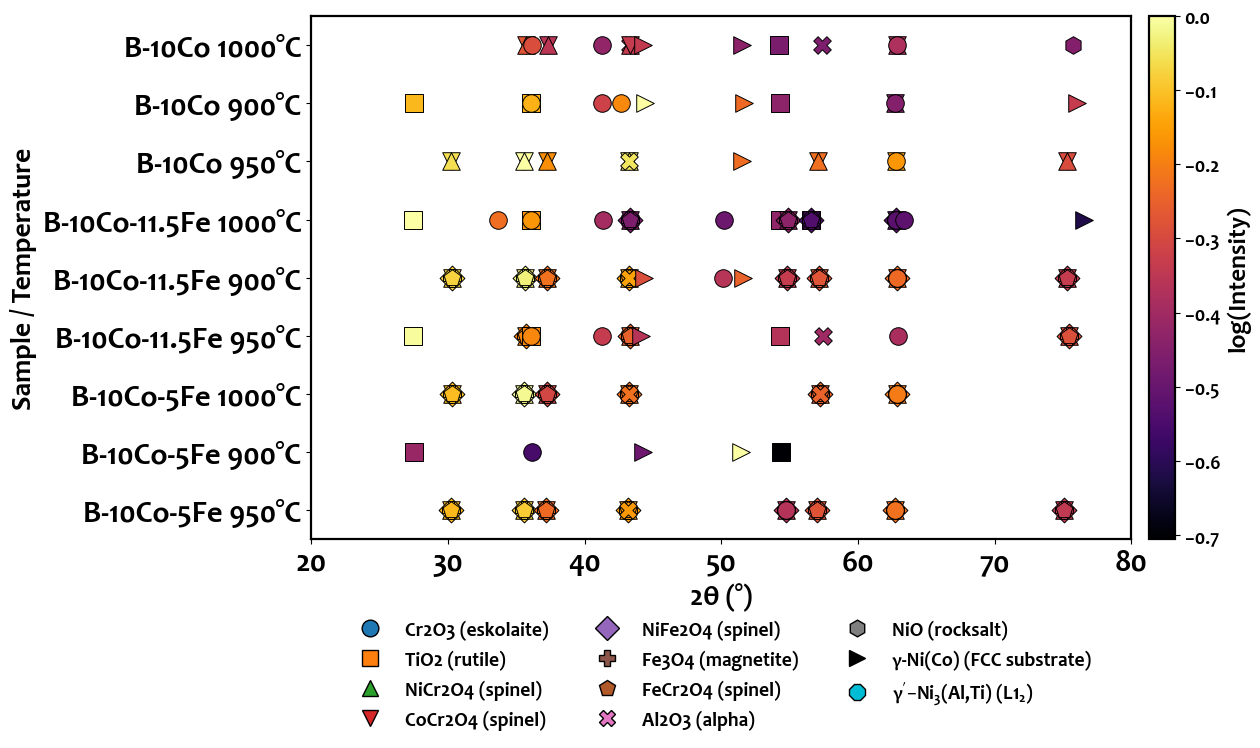

Saved: xrd_densometric_map.png


In [16]:
# === XRD 2D Densometric Map ===
# Local, no web/API — uses same anchor CSVs and phase library from previous code
# Color encodes log(I_norm) in [0–255]; x=2θ, y=sample, symbols by phase
# γ′ rendered as Ni3(Al,Ti) (L12) text label

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

# Read peak table from previous analysis
peak_table = pd.read_csv("xrd_peak_table.csv").dropna(subset=["phase"])
peak_table["logI"] = np.log10(np.clip(peak_table["I_norm"], 1e-4, 1.0))  # avoid negatives
peak_table["logI_scaled"] = 255 * (peak_table["logI"] - peak_table["logI"].min()) / (peak_table["logI"].max() - peak_table["logI"].min())

# Color map (log intensity -> RGB)
cmap = plt.get_cmap("inferno")
norm = Normalize(vmin=peak_table["logI"].min(), vmax=peak_table["logI"].max())

# Style
plt.rcParams.update({"font.family":"Candara","font.size":20,"font.weight":"bold"})
samples = list(dict.fromkeys(peak_table["sample"]))
sample_y = {s:i for i,s in enumerate(samples[::-1])}

# Phase marker/color table
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Al2O3 (alpha)":               ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
def phase_style(phase): return _PHASE_STYLES.get(phase, ("o","#333333"))

# === Plot ===
fig, ax = plt.subplots(figsize=(13,8))
for _, row in peak_table.iterrows():
    y = sample_y[row["sample"]]
    mk, base_color = phase_style(row["phase"])
    rgba = cmap(norm(row["logI"]))
    ax.scatter(row["two_theta_obs_deg"], y, marker=mk, s=160, color=rgba,
               edgecolors="k", linewidths=0.7, zorder=4)
    # optional label at strongest peaks
    if row["I_norm"] > 0.8:
        if "γ′" in row["phase"]:
            ax.text(row["two_theta_obs_deg"], y+0.15, "Ni₃(Al,Ti)", ha="center", va="bottom", fontsize=14, color="#00bcd4")

# Y-axis formatting
ax.set_yticks(range(len(samples)))
ax.set_yticklabels(samples[::-1])
ax.set_xlabel("2θ (°)")
ax.set_ylabel("Sample / Temperature")
ax.set_xlim(20,80)
ax.set_ylim(-0.5, len(samples)-0.5)
ax.grid(False)

# Legend — below figure
handles=[]; labels=[]
for ph,(mk,clr) in _PHASE_STYLES.items():
    handles.append(Line2D([0],[0], marker=mk, color="none", markerfacecolor=clr, 
                          markeredgecolor="k", markersize=12, label=ph))
labels = [r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)" if "γ′" in h.get_label() else h.get_label() for h in handles]
leg = ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12),
                frameon=False, fontsize=14)

# Colorbar (log intensity)
sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.035)
cbar.set_label("log(Intensity)", fontsize=18, weight="bold")
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.savefig("xrd_densometric_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: xrd_densometric_map.png")


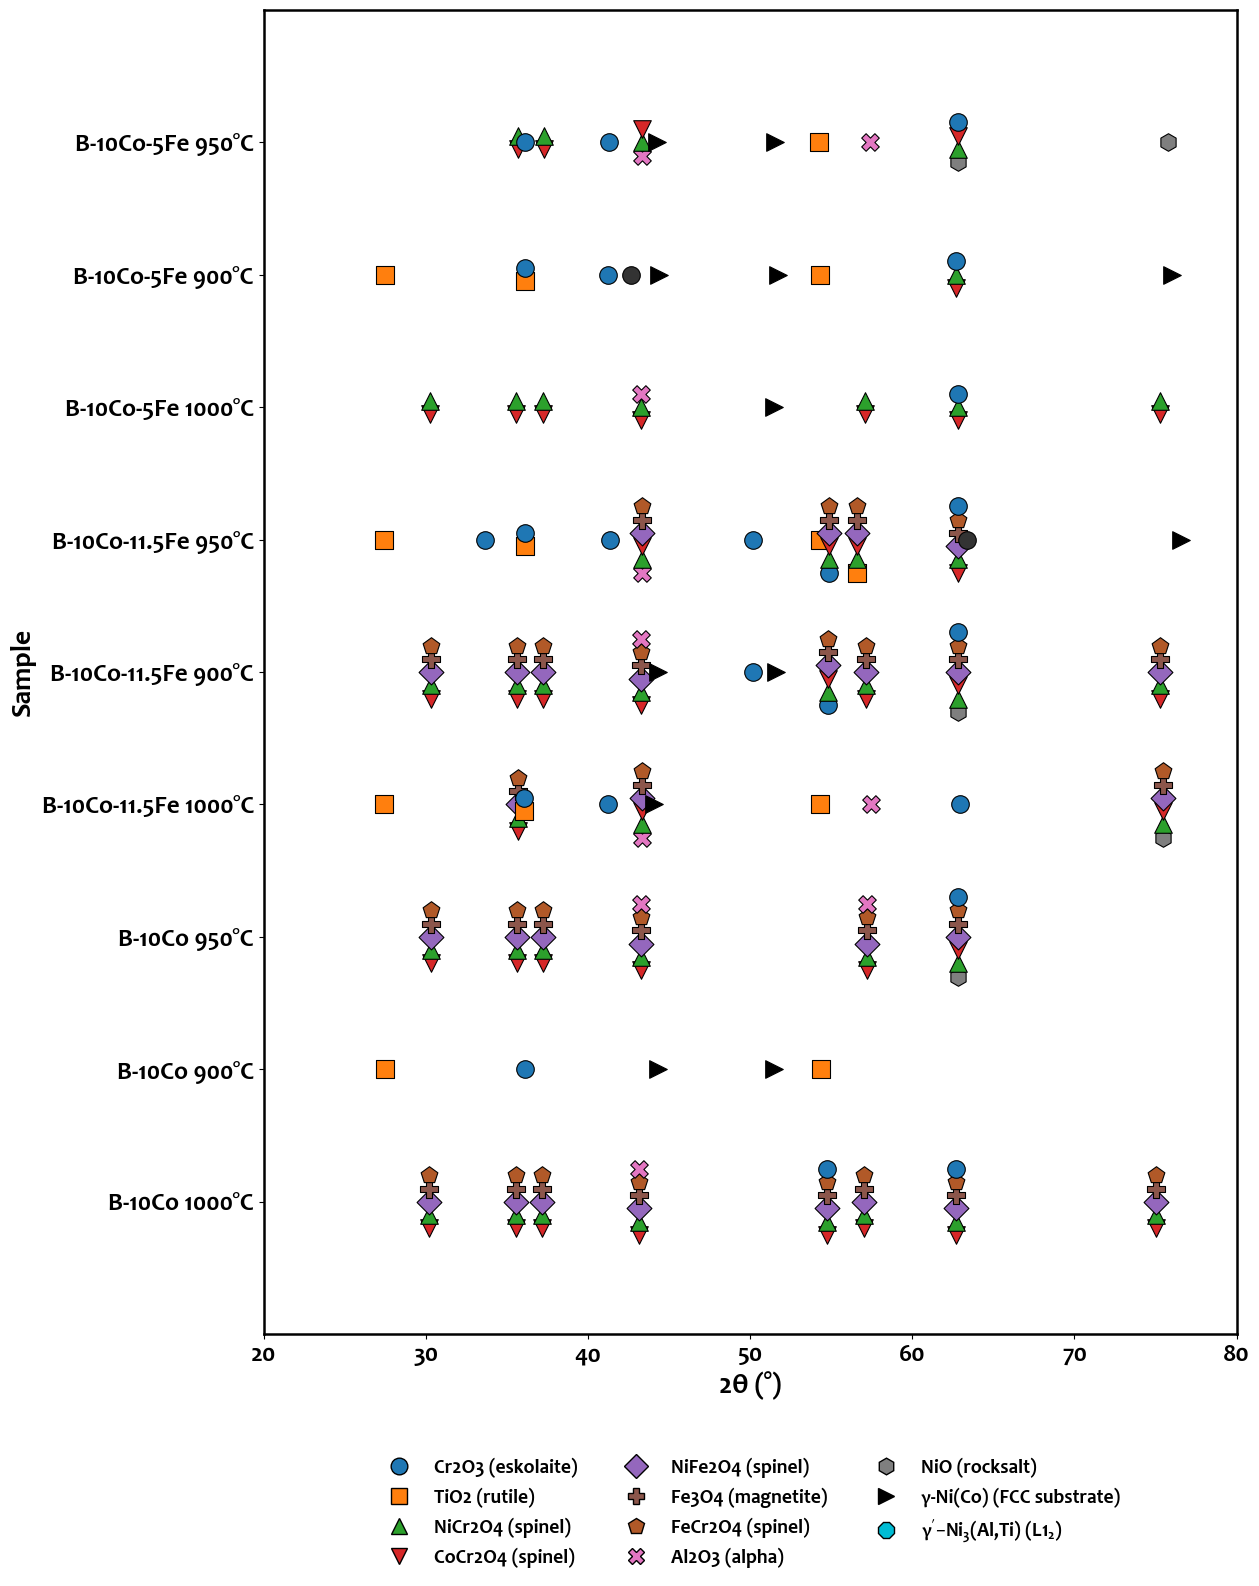

Saved: xrd_symbol_map.png


In [18]:
# === 2D Symbol-Only Phase Map (no overlap) ===
# Based on xrd_peak_table.csv from previous matching code
# Multiple phases at same 2θ are vertically offset and map is elongated accordingly.

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Load data
df = pd.read_csv("xrd_peak_table.csv").dropna(subset=["phase"])
df = df.sort_values(["sample","two_theta_obs_deg"]).reset_index(drop=True)

# --- Style
plt.rcParams.update({
    "font.family":"Candara","font.size":20,"font.weight":"bold",
    "axes.labelweight":"bold","axes.linewidth":1.8,
    "xtick.labelsize":18,"ytick.labelsize":18
})

# --- phase styles
_PHASE_STYLES = {
    "Cr2O3 (eskolaite)":           ("o", "#1f77b4"),
    "TiO2 (rutile)":               ("s", "#ff7f0e"),
    "NiCr2O4 (spinel)":            ("^", "#2ca02c"),
    "CoCr2O4 (spinel)":            ("v", "#d62728"),
    "NiFe2O4 (spinel)":            ("D", "#9467bd"),
    "Fe3O4 (magnetite)":           ("P", "#8c564b"),
    "FeCr2O4 (spinel)":            ("p", "#b15928"),
    "Al2O3 (alpha)":               ("X", "#e377c2"),
    "NiO (rocksalt)":              ("h", "#7f7f7f"),
    "γ-Ni(Co) (FCC substrate)":    (">", "#000000"),
    "γ′–Ni3(Al,Ti) (L12)":         ("8", "#00bcd4"),
}
LEGEND_LABEL = {
    "γ′–Ni3(Al,Ti) (L12)": r"$\gamma^\prime$–Ni$_3$(Al,Ti) (L1$_2$)"
}
def phase_style(ph): return _PHASE_STYLES.get(ph,("o","#333333"))

# --- Arrange samples
samples = list(dict.fromkeys(df["sample"]))
sample_y = {s:i for i,s in enumerate(samples[::-1])}

# --- parameters for vertical stacking
THETA_TOL = 0.25  # deg tolerance to consider "same angle"
STACK_DY  = 0.15  # vertical spacing per phase
BASE_DY   = 1.5   # spacing between samples

# --- compute per-sample stacked coordinates
rows=[]
for s in samples:
    sub = df[df["sample"]==s]
    base_y = sample_y[s]*BASE_DY
    for theta in sorted(sub["two_theta_obs_deg"].unique()):
        close = sub[np.abs(sub["two_theta_obs_deg"]-theta)<=THETA_TOL]
        n = len(close)
        if n==0: continue
        # assign stacked offsets
        offsets = np.linspace(-(n-1)/2, (n-1)/2, n)*STACK_DY
        for (r,off) in zip(close.itertuples(), offsets):
            rows.append((r.two_theta_obs_deg, base_y+off, r.phase))
stack_df = pd.DataFrame(rows, columns=["2theta","y","phase"])

# --- plot
fig_h = max(8, len(samples)*1.8)
fig, ax = plt.subplots(figsize=(13, fig_h))

for r in stack_df.itertuples():
    mk, col = phase_style(r.phase)
    ax.scatter(r._1, r.y, marker=mk, s=160, c=col, edgecolors="k", linewidths=0.8)

# --- decorate axes
ax.set_xlabel("2θ (°)")
ax.set_xlim(20,80)
ax.set_yticks([sample_y[s]*BASE_DY for s in samples])
ax.set_yticklabels(samples[::-1])
ax.set_ylabel("Sample")
ax.set_ylim(-BASE_DY, BASE_DY*(len(samples)))
ax.grid(False)

# --- legend
handles=[]; labels=[]
for ph,(mk,col) in _PHASE_STYLES.items():
    handles.append(Line2D([0],[0], marker=mk, color="none",
                          markerfacecolor=col, markeredgecolor="k",
                          markersize=12, linewidth=0, label=ph))
labels=[LEGEND_LABEL.get(h.get_label(),h.get_label()) for h in handles]
ax.legend(handles=handles, labels=labels, ncol=3, loc="upper center",
          bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=14)

plt.tight_layout()
plt.savefig("xrd_symbol_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: xrd_symbol_map.png")


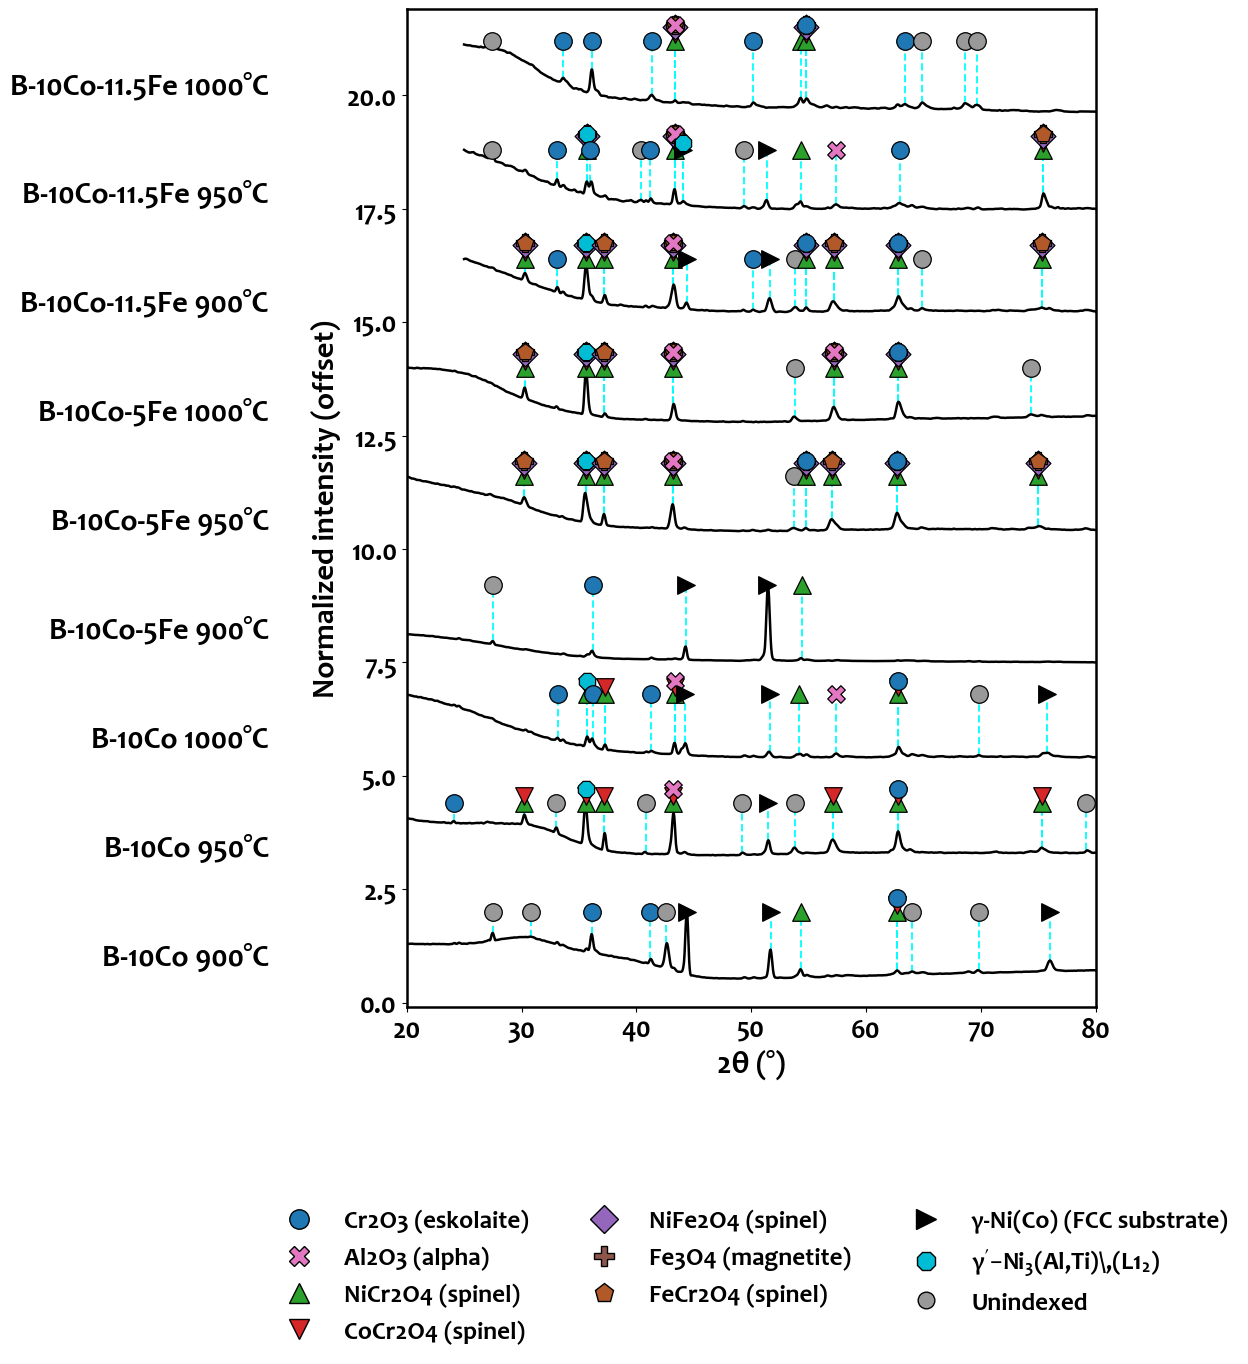

Saved: xrd_stacked_two_pass.png / .pdf


In [25]:
# ============================================================
# XRD STACKED PROFILES — TWO-PASS MATCH (INCLUDING UNINDEXED)
# ============================================================

import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import transforms as mtrans
from scipy.signal import savgol_filter, find_peaks

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0
SMOOTH_WINDOW, SMOOTH_POLY = 9, 3
PEAK_PROM, PEAK_WIDTH = 0.02, 1
TOL_PASS1, TOL_PASS2 = 0.35, 0.55
HEIGHT_SCALE = 2.0
OFFSET_STEP = HEIGHT_SCALE * 1.2
MARKER_STEP = 0.15
A_GPRIME = 3.58

DATA_FILES = [
    ("B-10Co 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 1000 anchor.CSV"),
]

# ---------------- STYLE ----------------
plt.rcParams.update({
    "font.family": "Candara",
    "font.size": 22,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.8,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ---------------- HELPERS ----------------
def normalize(y): return y / y.max() if y.max() > 0 else y
def smooth(y): return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)
def twotheta_from_hkl(a,h,k,l):
    d=a/np.sqrt(h*h+k*k+l*l)
    return 2*np.degrees(np.arcsin(LAMBDA/(2*d)))

def read_anchor(path):
    df=pd.read_csv(path,sep=None,engine="python",encoding="latin1")
    pos=[c for c in df.columns if "2" in c and "th" in c.lower()][0]
    inten=[c for c in df.columns if c.lower().startswith("i")][0]
    d=df[[pos,inten]].rename(columns={pos:"two_theta",inten:"Iobs"}).dropna()
    d["Iobs"]=normalize(smooth(d["Iobs"]))
    return d[(d["two_theta"]>=TWOTHETA_MIN)&(d["two_theta"]<=TWOTHETA_MAX)]

# ---------------- PHASE LIBRARY ----------------
def make_phase_lib(a=A_GPRIME):
    lib=[]
    def add(p,hkl,tt): lib.append((p,hkl,tt))
    # spinels
    for p in ["NiCr2O4 (spinel)","CoCr2O4 (spinel)","NiFe2O4 (spinel)","Fe3O4 (magnetite)","FeCr2O4 (spinel)"]:
        for tt,hkl in [(30.1,"220"),(35.5,"311"),(37.2,"222"),(43.2,"400"),
                       (47.3,"331/420"),(54.7,"422"),(57.0,"511"),(62.6,"440"),
                       (71.0,"620"),(73.7,"533"),(75.2,"622"),(77.4,"444")]:
            add(p,hkl,tt)
    # oxides + matrix
    for tt,hkl in [(24.5,"012"),(33.6,"104"),(36.2,"110"),(41.5,"113"),
                   (50.1,"024"),(54.8,"116"),(63.0,"300")]:
        add("Cr2O3 (eskolaite)",hkl,tt)
    for tt,hkl in [(25.6,"012"),(35.1,"104"),(37.8,"110"),(43.4,"113"),
                   (52.6,"024"),(57.5,"116"),(66.6,"300")]:
        add("Al2O3 (alpha)",hkl,tt)
    for tt,hkl in [(44.3,"111"),(51.7,"200"),(76.2,"220")]:
        add("γ-Ni(Co) (FCC substrate)",hkl,tt)
    for hkl,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),("200",(2,0,0))]:
        add("γ′–Ni3(Al,Ti) (L12)",hkl,twotheta_from_hkl(a,h,k,l))
    return pd.DataFrame(lib,columns=["phase","hkl","two_theta_ref_deg"])

PHASE_LIB=make_phase_lib()

PHASE_STYLE={
    "Cr2O3 (eskolaite)":("o","#1f77b4"),
    "Al2O3 (alpha)":("X","#e377c2"),
    "NiCr2O4 (spinel)":("^","#2ca02c"),
    "CoCr2O4 (spinel)":("v","#d62728"),
    "NiFe2O4 (spinel)":("D","#9467bd"),
    "Fe3O4 (magnetite)":("P","#8c564b"),
    "FeCr2O4 (spinel)":("p","#b15928"),
    "γ-Ni(Co) (FCC substrate)":(">","#000000"),
    "γ′–Ni3(Al,Ti) (L12)":("8","#00bcd4"),
}
LEGEND_LABEL={"γ′–Ni3(Al,Ti) (L12)":r"$\gamma^\prime$–Ni$_3$(Al,Ti)\,(L1$_2$)"}

# ---------------- MATCHING ----------------
def match_two_pass(df,label):
    pk,_=find_peaks(df["Iobs"],prominence=PEAK_PROM,width=PEAK_WIDTH)
    peaks=df.iloc[pk][["two_theta","Iobs"]].to_numpy()
    assigned=set()
    results=[]

    # Pass 1
    for ph,hkl,ref in PHASE_LIB.to_numpy():
        if ("Fe" in ph) and ("-5Fe" not in label) and ("-11.5Fe" not in label):
            continue
        diff=np.abs(peaks[:,0]-ref)
        j=np.argmin(diff)
        if diff[j]<=TOL_PASS1:
            results.append((peaks[j,0],peaks[j,1],ph,hkl))
            assigned.add(j)

    # Pass 2 (unmatched peaks)
    unmatched=[i for i in range(len(peaks)) if i not in assigned]
    for i in unmatched:
        tpk,ipk=peaks[i]
        diffs=np.abs(PHASE_LIB["two_theta_ref_deg"].values - tpk)
        j=np.argmin(diffs)
        if diffs[j]<=TOL_PASS2:
            r=PHASE_LIB.iloc[j]
            results.append((tpk,ipk,r["phase"],r["hkl"]))
        else:
            results.append((tpk,ipk,"Unindexed","—"))
    return results

# ---------------- BUILD ALL ----------------
profiles=[]
for label,f in DATA_FILES:
    if not os.path.exists(f):
        print(f"[WARN] Missing {f}")
        continue
    df=read_anchor(f)
    matches=match_two_pass(df,label)
    profiles.append((label,df["two_theta"].to_numpy(),df["Iobs"].to_numpy(),matches))

# ---------------- PLOT ----------------
fig_h=max(10,len(profiles)*OFFSET_STEP*0.7)
fig,ax=plt.subplots(figsize=(13,fig_h))
fig.subplots_adjust(left=0.45,right=0.98,top=0.96,bottom=0.30)
text_trans=mtrans.blended_transform_factory(ax.transAxes,ax.transData)

offset=0
for label,tt,yy,matches in profiles:
    ax.plot(tt,yy*HEIGHT_SCALE+offset,lw=1.8,color="k")
    ax.text(-0.20,offset+HEIGHT_SCALE*0.5,label,transform=text_trans,ha="right",va="center")
    grouped={}
    for tpk,ipk,ph,hkl in matches:
        grouped.setdefault(round(tpk,1),[]).append((ipk,ph))
    lane_top=offset+OFFSET_STEP-0.05
    for theta,grp in sorted(grouped.items()):
        for j,(ipk,ph) in enumerate(grp):
            mk,col=PHASE_STYLE.get(ph,("o","#999999"))
            ymark=min(offset+HEIGHT_SCALE+MARKER_STEP*j,lane_top)
            # dashed cyan connector
            ax.plot([theta,theta],[offset+ipk*HEIGHT_SCALE,ymark],
                    linestyle=(0,(4,2)),color="#00FFFF",linewidth=1.3,zorder=1)
            ax.scatter([theta],[ymark],marker=mk,s=160,
                       c=col,edgecolors="k",linewidths=0.9,zorder=5)
    offset+=OFFSET_STEP

ax.set_xlim(TWOTHETA_MIN,TWOTHETA_MAX)
ax.set_ylim(-0.1,offset+0.3)
ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")

# Legend
handles=[]
for ph,(mk,col) in PHASE_STYLE.items():
    handles.append(Line2D([0],[0],marker=mk,color="none",
                          markerfacecolor=col,markeredgecolor="k",
                          markersize=14,label=LEGEND_LABEL.get(ph,ph)))
handles.append(Line2D([0],[0],marker="o",color="none",
                      markerfacecolor="#999999",markeredgecolor="k",
                      markersize=12,label="Unindexed"))
ax.legend(handles=handles,ncol=3,loc="upper center",
          bbox_to_anchor=(0.5,-0.18),frameon=False,fontsize=18)

plt.savefig("xrd_stacked_two_pass.png",dpi=300,bbox_inches="tight")
plt.savefig("xrd_stacked_two_pass.pdf",dpi=300,bbox_inches="tight")
plt.show()
print("Saved: xrd_stacked_two_pass.png / .pdf")


Saved: xrd_peak_table_round2.csv  (248 peaks)


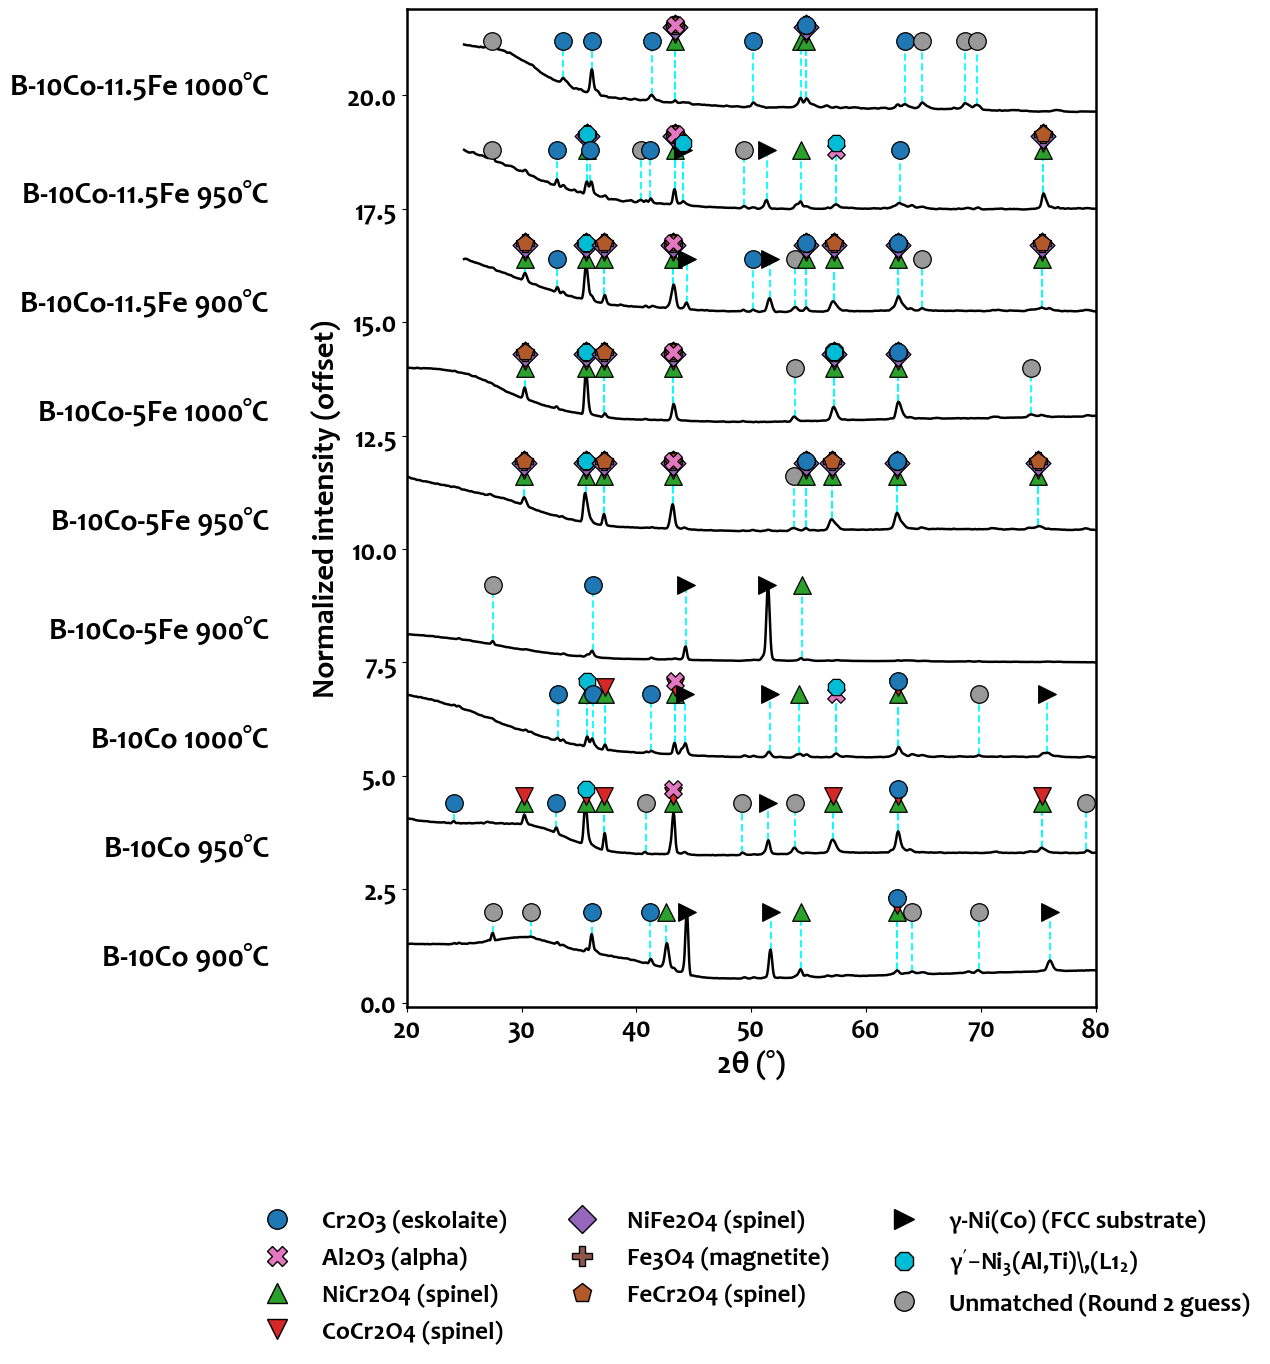

Saved plots and table successfully.


In [26]:
# ============================================================
# XRD STACKED PROFILES — CYAN CONNECTORS + ROUND-2 MATCH TABLE
# ============================================================

import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import transforms as mtrans
from scipy.signal import savgol_filter, find_peaks

# ---------------- CONFIG ----------------
LAMBDA = 1.5406
TWOTHETA_MIN, TWOTHETA_MAX = 20.0, 80.0
SMOOTH_WINDOW, SMOOTH_POLY = 9, 3
PEAK_PROMINENCE, PEAK_WIDTH = 0.02, 1
MATCH_TOL1, MATCH_TOL2 = 0.35, 0.6     # second round wider
A_GPRIME = 3.58

DATA_FILES = [
    ("B-10Co 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 900 anchor.CSV"),
    ("B-10Co 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 950 anchor.CSV"),
    ("B-10Co 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co 1000 anchor.CSV"),
    ("B-10Co-5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 900 achor.CSV"),
    ("B-10Co-5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 950 anchor.CSV"),
    ("B-10Co-5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co5Fe 1000 anchor.CSV"),
    ("B-10Co-11.5Fe 900°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 900 anchor.CSV"),
    ("B-10Co-11.5Fe 950°C",  r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 950 anchor.CSV"),
    ("B-10Co-11.5Fe 1000°C", r"H:\pd 1 nov\xrd ch3 part 2 oxidation\oxidation sudeepta ch3 oxi xrd scans and rietveld analysis\anchor\B10Co10Fe 1000 anchor.CSV"),
]

# ---------------- STYLE ----------------
plt.rcParams.update({
    "font.family": "Candara",
    "font.size": 22,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.linewidth": 1.8,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ---------------- HELPERS ----------------
def normalize(y): 
    y = np.asarray(y, float)
    return y / y.max() if y.max() > 0 else y

def smooth(y): return savgol_filter(y, SMOOTH_WINDOW, SMOOTH_POLY)

def d_from_two_theta(tt):
    theta = np.radians(tt/2)
    return LAMBDA / (2*np.sin(theta))

def twotheta_from_hkl(a, h,k,l):
    d = a / np.sqrt(h*h+k*k+l*l)
    return 2*np.degrees(np.arcsin(LAMBDA/(2*d)))

def read_anchor(path):
    df = pd.read_csv(path, sep=None, engine="python", encoding="latin1")
    pos = [c for c in df.columns if "2" in c and "th" in c.lower()][0]
    inten = [c for c in df.columns if c.lower().startswith("i")][0]
    d = df[[pos, inten]].rename(columns={pos:"two_theta", inten:"Iobs"}).dropna()
    d["Iobs"] = normalize(smooth(d["Iobs"]))
    return d[(d["two_theta"]>=TWOTHETA_MIN)&(d["two_theta"]<=TWOTHETA_MAX)]

# ---------------- PHASE LIBRARY ----------------
def make_phase_library(a=A_GPRIME):
    lib=[]
    def add(p,hkl,tt): lib.append((p,hkl,tt))
    for p in ["NiCr2O4 (spinel)","CoCr2O4 (spinel)","NiFe2O4 (spinel)",
              "Fe3O4 (magnetite)","FeCr2O4 (spinel)"]:
        for tt,hkl in [(30.1,"220"),(35.5,"311"),(37.2,"222"),(43.2,"400"),
                       (47.3,"331/420"),(54.7,"422"),(57.0,"511"),
                       (62.6,"440"),(71.0,"620"),(73.7,"533"),
                       (75.2,"622"),(77.4,"444")]:
            add(p,hkl,tt)
    for tt,hkl in [(24.5,"012"),(33.6,"104"),(36.2,"110"),(41.5,"113"),
                   (50.1,"024"),(54.8,"116"),(63.0,"300")]:
        add("Cr2O3 (eskolaite)",hkl,tt)
    for tt,hkl in [(25.6,"012"),(35.1,"104"),(37.8,"110"),(43.4,"113"),
                   (52.6,"024"),(57.5,"116"),(66.6,"300")]:
        add("Al2O3 (alpha)",hkl,tt)
    for tt,hkl in [(44.3,"111"),(51.7,"200"),(76.2,"220")]:
        add("γ-Ni(Co) (FCC substrate)",hkl,tt)
    for hkl,(h,k,l) in [("100",(1,0,0)),("110",(1,1,0)),("111",(1,1,1)),
                        ("200",(2,0,0)),("210",(2,1,0))]:
        add("γ′–Ni3(Al,Ti) (L12)",hkl,twotheta_from_hkl(a,h,k,l))
    return pd.DataFrame(lib,columns=["phase","hkl","two_theta_ref_deg"])

PHASE_LIB = make_phase_library()

PHASE_STYLE = {
    "Cr2O3 (eskolaite)":("o","#1f77b4"),
    "Al2O3 (alpha)":("X","#e377c2"),
    "NiCr2O4 (spinel)":("^","#2ca02c"),
    "CoCr2O4 (spinel)":("v","#d62728"),
    "NiFe2O4 (spinel)":("D","#9467bd"),
    "Fe3O4 (magnetite)":("P","#8c564b"),
    "FeCr2O4 (spinel)":("p","#b15928"),
    "γ-Ni(Co) (FCC substrate)":(">","#000000"),
    "γ′–Ni3(Al,Ti) (L12)":("8","#00bcd4"),
}
LEGEND_LABEL = {"γ′–Ni3(Al,Ti) (L12)":r"$\gamma^\prime$–Ni$_3$(Al,Ti)\,(L1$_2$)"}

# ---------------- PEAK MATCHING ----------------
def match_phases(df,label):
    pk,_=find_peaks(df["Iobs"],prominence=PEAK_PROMINENCE,width=PEAK_WIDTH)
    obs=df.iloc[pk][["two_theta","Iobs"]].to_numpy()
    matched=[]
    used=set()

    # ---- Round 1
    for ph,hkl,ref in PHASE_LIB.to_numpy():
        if ("Fe" in ph) and ("-5Fe" not in label) and ("-11.5Fe" not in label):
            continue
        diff=np.abs(obs[:,0]-ref)
        j=np.argmin(diff)
        if diff[j]<=MATCH_TOL1:
            matched.append((obs[j,0],obs[j,1],ph,hkl,ref,1))
            used.add(j)

    # ---- Round 2: fill unindexed
    for i,(tt,Ipk) in enumerate(obs):
        if i in used: continue
        diff=np.abs(PHASE_LIB["two_theta_ref_deg"].values-tt)
        j=np.argmin(diff)
        if diff[j]<=MATCH_TOL2:
            r=PHASE_LIB.iloc[j]
            matched.append((tt,Ipk,r.phase,r.hkl,r.two_theta_ref_deg,2))
            used.add(i)
        else:
            matched.append((tt,Ipk,"Unmatched",None,None,0))
    return matched

# ---------------- BUILD PROFILES ----------------
all_rows=[]; profiles=[]
for label,f in DATA_FILES:
    if not os.path.exists(f):
        print(f"[WARN] Missing:",f); continue
    df=read_anchor(f)
    matches=match_phases(df,label)
    profiles.append((label,df["two_theta"].to_numpy(),df["Iobs"].to_numpy(),matches))
    for tt,Ipk,ph,hkl,ref,rd in matches:
        all_rows.append({
            "sample":label,
            "two_theta_obs_deg":round(float(tt),3),
            "d_obs_A":round(float(d_from_two_theta(tt)),4),
            "I_norm":round(float(Ipk),4),
            "phase":ph,"hkl":hkl,
            "ref_two_theta":ref,
            "delta_deg":None if ref is None else round(tt-ref,3),
            "match_round":rd
        })

peak_table=pd.DataFrame(all_rows)
peak_table.to_csv("xrd_peak_table_round2.csv",index=False)
print(f"Saved: xrd_peak_table_round2.csv  ({len(peak_table)} peaks)")

# ---------------- PLOT ----------------
HEIGHT_SCALE=2.0
OFFSET_STEP=HEIGHT_SCALE*1.2
MARKER_STEP=0.15

fig_h=max(10,len(profiles)*OFFSET_STEP*0.7)
fig,ax=plt.subplots(figsize=(13,fig_h))
fig.subplots_adjust(left=0.45,right=0.98,top=0.96,bottom=0.30)
text_trans=mtrans.blended_transform_factory(ax.transAxes,ax.transData)

offset=0.0
for label,tt,yy,matches in profiles:
    ax.plot(tt,yy*HEIGHT_SCALE+offset,lw=1.8,color="k")
    ax.text(-0.20,offset+HEIGHT_SCALE*0.5,label,transform=text_trans,ha="right",va="center")

    grouped={}
    for tpk,ipk,ph,_,_,rd in matches:
        grouped.setdefault(round(tpk,1),[]).append((ipk,ph,rd))
    lane_top=offset+OFFSET_STEP-0.05
    for theta,grp in sorted(grouped.items()):
        for j,(ipk,ph,rd) in enumerate(grp):
            mk,col=PHASE_STYLE.get(ph,("o","#999" if ph=="Unmatched" else "#333"))
            ymark=min(offset+HEIGHT_SCALE+MARKER_STEP*j,lane_top)
            ax.plot([theta,theta],[offset+ipk*HEIGHT_SCALE,ymark],
                    linestyle=(0,(4,2)),color="#00FFFF",linewidth=1.3,zorder=1)
            ax.scatter([theta],[ymark],marker=mk,s=160,c=col,
                       edgecolors="k",linewidths=0.9,zorder=5)
    offset+=OFFSET_STEP

ax.set_xlim(TWOTHETA_MIN,TWOTHETA_MAX)
ax.set_ylim(-0.1,offset+0.3)
ax.set_xlabel("2θ (°)")
ax.set_ylabel("Normalized intensity (offset)")

handles=[]
for ph,(mk,col) in PHASE_STYLE.items():
    handles.append(Line2D([0],[0],marker=mk,color="none",
                          markerfacecolor=col,markeredgecolor="k",
                          markersize=14,label=LEGEND_LABEL.get(ph,ph)))
handles.append(Line2D([0],[0],marker="o",color="none",
                      markerfacecolor="#999",markeredgecolor="k",
                      markersize=14,label="Unmatched (Round 2 guess)"))
ax.legend(handles=handles,ncol=3,loc="upper center",
          bbox_to_anchor=(0.5,-0.18),frameon=False,fontsize=18)

plt.savefig("xrd_stacked_round2.png",dpi=300,bbox_inches="tight")
plt.savefig("xrd_stacked_round2.pdf",dpi=300,bbox_inches="tight")
plt.show()
print("Saved plots and table successfully.")
